# CLO DUAL JSON MAKER COVER ARC DATA 
Centerpoint 기준으로 arrangement point하지 않고

각 패널의 Mean Point를 기준으로 arrangement point 생성

++ 추가적으로 ARC 2 Bezier data에 대해서도 다룰 수 있게 됨.ㅋ.ㅋ

++ 내부의 Internal Line 데이터까지 추가 하는 Version 2025.02.18 기준

In [140]:
import numpy as np

# TODO: 2025.03.03 front, back body 부분 배치포인트 1단계씩 올림.
batch_points = {
"Arm_Back_1_L" : [ 20.4240,  132.30371, -15.25501],
"Arm_Back_2_L" : [ 25.4240,  127.80371, -15.25501],
"Arm_Back_3_L" : [ 30.4240,  123.30371, -15.25501],
"Arm_Back_4_L" : [ 35.4240,  118.80371, -15.25501],
"Arm_Back_5_L" : [ 40.4240,  114.30371, -15.25501],
"Arm_Back_6_L" : [ 45.4240,  109.80371, -15.25501],
"Arm_Back_7_L" : [ 50.4240,  105.30371, -15.25501],
"Arm_Back_8_L" : [ 55.4240,  100.80371, -15.25501],
"Arm_Back_1_R" : [ -20.4240,  132.30371, -15.25501],
"Arm_Back_2_R" : [ -25.4240,  127.80371, -15.25501],
"Arm_Back_3_R" : [ -30.4240,  123.30371, -15.25501],
"Arm_Back_4_R" : [ -35.4240,  118.80371, -15.25501],
"Arm_Back_5_R" : [ -40.4240,  114.30371, -15.25501],
"Arm_Back_6_R" : [ -45.4240,  109.80371, -15.25501],
"Arm_Back_7_R" : [ -50.4240,  105.30371, -15.25501],
"Arm_Back_8_R" : [ -55.4240,  100.80371, -15.25501],
"Arm_Front_1_L" : [ 20.4240,  132.30371, 15.25501],
"Arm_Front_2_L" : [ 25.4240,  127.80371, 15.25501],
"Arm_Front_3_L" : [ 30.4240,  123.30371, 15.25501],
"Arm_Front_4_L" : [ 35.4240,  118.80371, 15.25501],
"Arm_Front_5_L" : [ 40.4240,  114.30371, 15.25501],
"Arm_Front_6_L" : [ 45.4240,  109.80371, 15.25501],
"Arm_Front_7_L" : [ 50.4240,  105.30371, 15.25501],
"Arm_Front_8_L" : [ 55.4240,  100.80371, 15.25501],
"Arm_Front_1_R" : [ -20.4240,  132.30371, 15.25501],
"Arm_Front_2_R" : [ -25.4240,  127.80371, 15.25501],
"Arm_Front_3_R" : [ -30.4240,  123.30371, 15.25501],
"Arm_Front_4_R" : [ -35.4240,  118.80371, 15.25501],
"Arm_Front_5_R" : [ -40.4240,  114.30371, 15.25501],
"Arm_Front_6_R" : [ -45.4240,  109.80371, 15.25501],
"Arm_Front_7_R" : [ -50.4240,  105.30371, 15.25501],
"Arm_Front_8_R" : [ -55.4240,  100.80371, 15.25501],
"Body_Front_Center_1" :[  0., 142.30371, 15.25501],
"Body_Front_Center_2" : [  0., 135.30371, 15.25501],
"Body_Front_Center_3" : [  0., 128.30371, 15.25501],
"Body_Front_Center_4" : [  0., 121.30371, 15.25501],
"Body_Front_Center_5" : [  0., 114.30371, 15.25501],
"Body_Front_Center_6" : [  0., 107.30371, 15.25501],
"Body_Front_Center_7" : [  0., 100.30371, 15.25501],
"Body_Front_Center_8" : [  0., 93.30371, 15.25501],
"Body_Front_Center_9" : [  0., 79.30371, 15.25501],
"Body_Back_Center_1" : [  0., 142.30371,-15.25501],
"Body_Back_Center_2" : [  0., 135.30371,-15.25501],
"Body_Back_Center_3" : [  0., 128.30371,-15.25501],
"Body_Back_Center_4" : [  0., 121.30371,-15.25501],
"Body_Back_Center_5" : [  0., 114.30371,-15.25501],
"Body_Back_Center_6" : [  0., 107.30371,-15.25501],
"Body_Back_Center_7" : [  0., 100.30371,-15.25501],
"Body_Back_Center_8" : [  0., 93.30371, -15.25501],
"Body_Back_Center_9" : [  0., 86.30371, -15.25501],
"Body_Back_Center_10": [  0., 75.30371, -15.25501],
#"Body_Front_1_R" : [ -11.86359, 142.30371,   15.25501],
"Body_Front_1_R" : [ -11.86359, 135.30371,   15.25501],
"Body_Front_2_R" : [ -11.86359, 128.30371,   15.25501],
"Body_Front_3_R" : [ -11.86359, 121.30371,   15.25501],
"Body_Front_4_R" : [ -11.86359, 114.30371,   15.25501],
"Body_Front_5_R" : [ -11.86359, 107.30371,   15.25501],
"Body_Front_6_R" : [ -11.86359, 100.30371,   15.25501],
#"Body_Front_1_L" : [ 11.86359, 142.30371,   15.25501],
"Body_Front_1_L" : [ 11.86359, 135.30371,   15.25501],
"Body_Front_2_L" : [ 11.86359, 128.30371,   15.25501],
"Body_Front_3_L" : [ 11.86359, 121.30371,   15.25501],
"Body_Front_4_L" : [ 11.86359, 114.30371,   15.25501],
"Body_Front_5_L" : [ 11.86359, 107.30371,   15.25501],
"Body_Front_6_L" : [ 11.86359, 100.30371,   15.25501],
#"Body_Back_1_R" :[ -11.86359, 142.30371,   -15.25501],
"Body_Back_1_R" :[ -11.86359, 135.30371,   -15.25501],
"Body_Back_2_R" :[ -11.86359, 128.30371,   -15.25501],
"Body_Back_3_R" :[ -11.86359, 121.30371,   -15.25501],
"Body_Back_4_R" :[ -11.86359, 114.30371,   -15.25501],
"Body_Back_5_R" :[ -11.86359, 107.30371,   -15.25501],
"Body_Back_6_R" :[ -11.86359, 100.30371,   -15.25501],
#"Body_Back_1_L" :[ 11.86359, 142.30371,   -15.25501],
"Body_Back_1_L" :[ 11.86359, 135.30371,   -15.25501],
"Body_Back_2_L" :[ 11.86359, 128.30371,   -15.25501],
"Body_Back_3_L" :[ 11.86359, 121.30371,   -15.25501],
"Body_Back_4_L" :[ 11.86359, 114.30371,   -15.25501],
"Body_Back_5_L" :[ 11.86359, 107.30371,   -15.25501],
"Body_Back_6_L" :[ 11.86359, 100.30371,   -15.25501],
"Leg_Front_1_L" : [ 9.86359, 78.30371,  15.25501], 
"Leg_Front_2_L" : [ 9.86359, 68.30371,  15.25501],
"Leg_Front_3_L" : [ 9.86359, 58.30371,  15.25501],
"Leg_Front_1_R" :[ -9.86359, 78.30371,  15.25501], 
"Leg_Front_2_R" :[ -9.86359, 68.30371,  15.25501],
"Leg_Front_3_R" :[ -9.86359, 58.30371,  15.25501], 
"Leg_Back_1_L" :  [ 9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_L" :  [ 9.86359, 68.30371,  -15.25501],
"Leg_Back_3_L" :  [ 9.86359, 58.30371,  -15.25501],
"Leg_Back_1_R" : [ -9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_R" : [ -9.86359, 68.30371,  -15.25501],
"Leg_Back_3_R" : [ -9.86359, 58.30371,  -15.25501],
"Leg_Front_Mid_1" :[-13.86359, 54.30371, 15.25501],
"Leg_Front_Mid_3" :[13.86359, 54.30371, 15.25501],
"Leg_Back_Mid_1" :[13.86359, 54.30371, -15.25501],
"Leg_Back_Mid_3" :[-13.86359, 54.30371, -15.25501],
"Skirt_Front_Center_1":[0, 50.30371, 15.25501],
"Skirt_Front_Center_2":[0, 42.30371, 15.25501],
"Skirt_Front_Center_3":[0, 36.30371, 15.25501],
"Skirt_Front_Center_4":[0, 30.30371, 15.25501],
"Skirt_Front_Center_5":[0, 18.30371, 15.25501],
"Skirt_Front_Center_6" : [0, 6.30371, 15.25501],
"Skirt_Back_Center" : [0, 54.30371, -15.25501],
"Skirt_Back_Center_1" :[0, 50.30371, -15.25501],
"Skirt_Back_Center_2" :[0, 42.30371, -15.25501],
"Skirt_Back_Center_3" :[0, 36.30371, -15.25501],
"Skirt_Back_Center_4" :[0, 30.30371, -15.25501],
"Skirt_Back_Center_5" :[0, 18.30371, -15.25501],
"Skirt_Back_Center_6" :[0, 6.30371, -15.25501],
"Leg_Front_Mid_L" : [9.86359, 48.30371, 15.25501], 
"Leg_Front_Mid_R" :[-9.86359, 48.30371, 15.25501], 
"Leg_Back_Mid_L" :[9.86359, 48.30371, -15.25501],
"Leg_Back_Mid_R" :[-9.86359, 48.30371, -15.25501],
"Shoulder_Top_L" : [  11.424, 142.30371, 0.],
"Shoulder_Top_R": [  -11.424, 142.30371, 0.],
"Neck_L" :[  5.424, 149.30371, 1.],
"Neck_R" :[  -5.424, 149.30371, 1.],
"Neck_Back_Center" :[  0., 149.30371, -15.25501],
"Neck_Front_Center" :[  0., 145.30371, 15.25501],
#"Head_L" : [ 10., 160.30371, 0],
#"Head_R" : [ -10., 160.30371, 0],
"Head_Back_L" : [ 7., 160.30371, -15.25501],
"Head_Back_R" : [ -7., 160.30371, -15.25501],
"Head_Back_Center" :[ 0., 160.30371, -15.25501],
"Head_Front_Center" : [ 0., 160.30371, 15.25501],
"Head_L" :[ 5., 172.30371, 0], #Head_Top_L  인걸 바꿈
"Head_R" :[ -5., 172.30371, 0], #Head_Top_R  인걸 바꿈
"Head_Top_Center" : [ 0., 172.30371, 0],
"Leg_Front_Point_1" :[18.86359, 22.30371, 15.25501],
"Leg_Front_Point_2" :[11.86359, 22.30371, 15.25501],
"Leg_Front_Point_3" :[4.86359, 22.30371, 15.25501],
"Leg_Front_Point_4" :[-4.86359, 22.30371, 15.25501],
"Leg_Front_Point_5" :[-11.86359, 22.30371, 15.25501],
"Leg_Front_Point_6" :[-18.86359, 22.30371, 15.25501],
"Leg_Back_Point_1" :[18.86359, 22.30371, -15.25501],
"Leg_Back_Point_2" :[11.86359, 22.30371, -15.25501],
"Leg_Back_Point_3" :[4.86359, 22.30371, -15.25501],
"Leg_Back_Point_4" :[-4.86359, 22.30371, -15.25501],
"Leg_Back_Point_5" :[-11.86359, 22.30371, -15.25501], 
"Leg_Back_Point_6" :[-18.86359, 22.30371, -15.25501],
}

for key, value in batch_points.items():
    batch_points[key] = [value[0], value[1] -10, value[2]]
    

def matching_point(target_point):
# 모든 batch_point들과 target_point 간의 거리(L2 norm) 계산
    keys = list(batch_points.keys())  # batch_point의 key 목록
    values = np.array(list(batch_points.values()))  # value를 numpy 배열로 변환

    # L2 거리 계산 (유클리드 거리)
    distances = np.linalg.norm(values - target_point, axis=1)

    # 가장 가까운 key 찾기
    closest_index = np.argmin(distances)  # 최소 거리의 인덱스
    closest_key = keys[closest_index]  # 해당 인덱스의 key 가져오기

    #print(f"가장 가까운 batch_point: {closest_key}")
    
    return closest_key    

In [1]:
import os, sys
from pprint import pprint
import matplotlib.pyplot as plt
import matplotlib.patches as patches






sys.path.append(os.path.dirname(os.getcwd()))
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
from env_constants import PYGARMENT_ROOT, DATASET_ROOT

module_path = os.path.abspath(os.path.dirname(os.getcwd()))
if module_path not in sys.path:
    sys.path.append(module_path)



sys.path.append(PYGARMENT_ROOT)
import pygarment as pyg


In [ ]:
import os 
import sys

sys.path.append(os.path.dirname(os.getcwd()))
from env_constants import PYGARMENT_ROOT
sys.path.append(PYGARMENT_ROOT)
import pygarment as pyg

import pickle
import numpy as np
import svgpathtools as svgpath
from PIL import Image
from copy import deepcopy
from torch.utils.data import Dataset
import random


from dataclasses import dataclass, field
from typing import List, Dict, Tuple
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


@dataclass
class Stitch :
    panel_0 : str
    edge_0 : int
    panel_1 : str
    edge_1 : int
    stitch_direction : bool
    

class StitchDict:
    def __init__(self, raw_stitch_dict: Dict[int, List[Dict]]):
        """
        Initialize the StitchManager from a raw stitch dictionary.        
        raw_stitch_dict: keys are stitch ids and values are lists of two dictionaries
        with 'panel' and 'edge' keys.
        """
        self._stitches: Dict[int, Stitch] = {}
        for stitch_id, stitch_pair in raw_stitch_dict.items():
            # Each stitch_pair contains two entries representing the two sides of the stitch.
            side0 = stitch_pair[0]
            side1 = stitch_pair[1]
            # Optionally, you could compute stitch_direction from panel names or edges.
            stitch_direction = False  # You can update this logic as needed.
            self._stitches[stitch_id] = Stitch(
                panel_0=side0['panel'],
                edge_0=side0['edge'],
                panel_1=side1['panel'],
                edge_1=side1['edge'],
                stitch_direction=stitch_direction
            )
    
    def reindex(
        self,
        mapping: Dict[int, int],
    ) -> None:
        """
        Re-index the internal dictionary using a provided mapping.
        For example, mapping could be ann_to_img_seam_idx_map or img_to_ann_seam_idx_map.
        """
        new_stitches = {}
        for old_key, stitch in self._stitches.items():
            new_key = mapping.get(old_key, old_key)
            new_stitches[new_key] = stitch
        self._stitches = new_stitches
    
    def __getitem__(self, key: int) -> Stitch:
        return self._stitches[key]
    
    def __setitem__(self, key: int, value: Stitch) -> None:
        self._stitches[key] = value
    
    def items(self):
        return self._stitches.items()

    def __len__(self):
        return len(self._stitches)
    
    def __repr__(self):
        return repr(self._stitches)



In [113]:

import math


class SVGPanel:
    def __init__(self, svg_path: List[svgpath.Path]):
        self.svg_path = svg_path
        
    @property
    def edge_len_list(self) :
        return [edge.length() for edge in self.svg_path]
    
    @property
    def normalized_edge_stt(self, edge_idx : int) :
        return sum(self.edge_len_list[:edge_idx]) / sum(self.edge_len_list)
        
    @property
    def normalized_edge_end(self, edge_idx : int) :
        return sum(self.edge_len_list[:edge_idx+1]) / sum(self.edge_len_list)
    
    def translate(self, dx: float, dy: float) -> None:
        """
        Translate the panel by dx along x-axis and dy along y-axis.
        """
        # In the complex plane, translation by (dx, dy) means adding (dx + dy*j)
        delta = dx + dy * 1j
        self.svg_path = svgpath.Path(*[path.translated(delta) for path in self.svg_path])


    def scale(self, factor: float, pivot: np.ndarray = np.array([0, 0])) -> None:
        """
        Scale the panel by the given factor relative to the pivot.
        By default, the pivot is 0 (the origin), but you can specify a different pivot point.
        """
        pivot_complex = pivot[0] + pivot[1] * 1j
        self.svg_path = svgpath.Path(*[
            (path.translated(-pivot_complex)).scaled(factor).translated(pivot_complex) for path in self.svg_path
        ])
        
    def rotate_clockwise(self, angle_degrees: float, pivot: np.ndarray = np.array([0, 0])) -> None:
        """
        Rotate the entire path by a given angle in degrees around a pivot point.
        
        Args:
            angle_degrees: The angle to rotate the path, in degrees.
            pivot: The point around which to rotate the path. Default is the origin (0+0j).
        """
        pivot_complex = pivot[0] + pivot[1] * 1j
        self.svg_path = svgpath.Path(*[
            path.rotated(angle_degrees, pivot_complex) for path in self.svg_path
        ])
        
    def mirror_horizontal(self) -> None:
        """
        Mirror the panel horizontally (flip the x-axis).
        """
        # self.svg_path = [svgpath.Path(*[self._mirror_horizontal_segment(seg) for seg in path]) for path in self.svg_path]
        self.svg_path = svgpath.Path(*[self._mirror_horizontal_segment(seg) for seg in self.svg_path])        

    def mirror_vertical(self) -> None:
        """
        Mirror the panel vertically (flip the y-axis).
        """
        # self.svg_path = [svgpath.Path(*[self._mirror_vertical_segment(seg) for seg in path]) for path in self.svg_path]
        self.svg_path = svgpath.Path(*[self._mirror_vertical_segment(seg) for seg in self.svg_path])

    def _mirror_horizontal_segment(self, segment):
        if isinstance(segment, svgpath.Arc):
            # Mirror the start and end points horizontally
            start = complex(-segment.start.real, segment.start.imag)
            end = complex(-segment.end.real, segment.end.imag)
            # Reverse the sweep flag
            sweep = not segment.sweep
            return svgpath.Arc(start=start, radius=segment.radius, rotation=segment.rotation,
                       large_arc=segment.large_arc, sweep=sweep, end=end)
        else:
            return segment.scaled(-1, 1)

    def _mirror_vertical_segment(self, segment):
        if isinstance(segment, svgpath.Arc):
            # Mirror the start and end points vertically
            start = complex(segment.start.real, -segment.start.imag)
            end = complex(segment.end.real, -segment.end.imag)
            # Reverse the sweep flag
            sweep = not segment.sweep
            return svgpath.Arc(start=start, radius=segment.radius, rotation=segment.rotation,
                       large_arc=segment.large_arc, sweep=sweep, end=end)
        else:
            return segment.scaled(1, -1)

    def draw(
        self,
        ax          : plt.Axes = None,
        panel_name  : str = None,
        N_SAMPLE_PER_EDGE : int = 80,
        stitch_list : List[int] = None,
        edge_color_list : List[Tuple[float, float, float]] = None
    ) -> None:
        if stitch_list is not None :
            assert len(stitch_list) == len(self.svg_path), "stitch_list must be the same length as the number of edges"
        if ax is None :
            ax = plt.gca()
        if panel_name is not None :
            ax.set_title(panel_name)
        if edge_color_list is None :
            edge_color_list = plt.cm.rainbow(np.linspace(0, 1, len(self.svg_path)))
         
        path_start_pos = np.array([self.svg_path[0].start.real, self.svg_path[0].start.imag])   
        for dx, dy in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
            ax.annotate(
                "0",
                path_start_pos + np.array([dx, dy]),
                color = "white", fontweight = "bold",
                fontsize = 9
            )
        ax.annotate(
            "0",
            path_start_pos,
            color = "black", # fontweight = "bold",
            fontsize = 9
        )
        for edge_idx, (edge, edge_color) in enumerate(zip(self.svg_path, edge_color_list)) :
            ax.add_patch(
                FancyArrowPatch(
                    [edge.start.real, edge.start.imag],
                    [edge.end.real, edge.end.imag],
                    arrowstyle='-|>',
                    mutation_scale=15,
                    color = "black",
                    linewidth = 0.5
                )
            )
            ax.scatter(
                list(map(lambda t : edge.point(t).real, np.linspace(0, 1, N_SAMPLE_PER_EDGE))),
                list(map(lambda t : edge.point(t).imag, np.linspace(0, 1, N_SAMPLE_PER_EDGE))),
                s = 0.5, color = edge_color
            )
            if stitch_list is not None :
                # for dx, dy in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
                #     ax.annotate(
                #         f"{stitch_list[edge_idx]}",
                #         [
                #             (edge.start.real + edge.end.real) / 2 + dx,
                #             (edge.start.imag + edge.end.imag) / 2 + dy
                #         ],
                #         color = "white", # fontweight = "bold",
                #         fontsize = 11, fontweight = "bold"
                #     )
                ax.annotate(
                    f"{stitch_list[edge_idx]}",
                    [
                        (edge.start.real + edge.end.real) / 2,
                        (edge.start.imag + edge.end.imag) / 2
                    ],
                    color = edge_color,
                    fontsize = 11, fontweight = "bold"
                )
        ax.invert_yaxis()
        ax.axis("equal")
        
    def is_clockwise(self) -> bool:
        """
        Determine if the path is clockwise.
        """
        total = 0
        for segment in self.svg_path:
            start = segment.start
            end = segment.end
            total += (end.real - start.real) * (end.imag + start.imag)
        return total <= 0

    def reverse_path(self) -> None:
        """
        Reverse the order of the path segments and their directions.
        """
        reversed_segments = []
        for segment in reversed(self.svg_path):
            reversed_segment = segment.reversed()
            reversed_segments.append(reversed_segment)
        self.svg_path = svgpath.Path(*reversed_segments)
        
    def set_start(self, idx: int) -> None :
        """
        Set the start point of the path to the point at index idx.
        """
        self.svg_path = svgpath.Path(*(self.svg_path[idx:] + self.svg_path[:idx]))

    def min_distance_to_point(self, point: complex) -> float:
        """
        Calculate the minimum distance from any point on the panel to a given point.
        
        Args:
            point: A complex number representing the point in the complex plane.
            
        Returns:
            float: The minimum distance from any point on the panel to the given point.
        """
        min_distance = float('inf')
        for path in self.svg_path:
            for segment in path:
                distance = segment.distance(point)
                if distance < min_distance:
                    min_distance = distance
        return min_distance
    
    def bbox(self) :
        """
        (xmin, ymin, xmax, ymax)
        """
        xmin, xmax, ymin, ymax = svgpath.Path(*self.svg_path).bbox()
        return xmin, ymin, xmax, ymax
    
    def get_center(self) :
        xmin, ymin, xmax, ymax = self.bbox()
        return np.array([(xmin + xmax) / 2, (ymin + ymax) / 2])
    
    def __repr__(self):
        return f"Panel(svg_path={self.svg_path})"

    def approximate_quadratic_bezier_with_cubic_bezier(self, VIS : bool = False) :
        for i, edge in enumerate(self.svg_path):
            if isinstance(edge, svgpath.QuadraticBezier):
                # Convert quadratic to cubic using the standard formula:
                # CP1 = start + 2/3 * (control - start)
                # CP2 = end + 2/3 * (control - end)
                start = edge.start
                end = edge.end
                control = edge.control
                
                cp1 = start + (control - start) * (2/3)
                cp2 = end + (control - end) * (2/3)
                
                self.svg_path[i] = svgpath.CubicBezier(start, cp1, cp2, end)
                
                if VIS :
                    t_list = np.linspace(0, 1, 100)
                    plt.figure(figsize=(10, 10))
                    plt.title("quadratic => cubic bezier")
                    plt.plot(
                        list(map(lambda t : edge.point(t).real, t_list)),
                        list(map(lambda t : edge.point(t).imag, t_list)),
                        color = "black"
                    )
                    plt.plot(
                        list(map(lambda t : self.svg_path[i].point(t).real, t_list)),
                        list(map(lambda t : self.svg_path[i].point(t).imag, t_list)),
                        color = "red"
                    )
                    plt.axis("equal")
                    plt.show()
        return self
    
    def approximate_arc_with_cubic_bezier(self, VIS : bool = False) :
        for i, edge in enumerate(self.svg_path):
            if isinstance(edge, svgpath.Arc):
                x1 = edge.start.real
                y1 = edge.start.imag
                x2 = edge.end.real
                y2 = edge.end.imag
                rx = edge.radius.real
                ry = edge.radius.imag
                rotation = edge.rotation
                large_arc = edge.large_arc
                sweep = edge.sweep
                
                phi_rad = math.radians(rotation)
                cx = (x1 - x2) / 2.0
                cy = (y1 - y2) / 2.0
                
                            
                # x1', y1'
                x1p = math.cos(phi_rad)*cx + math.sin(phi_rad)*cy
                y1p = -math.sin(phi_rad)*cx + math.cos(phi_rad)*cy
                
                # Step 2: rx,ry 스케일링 체크 (여기서는 필요 없으리라 가정)
                lam = (x1p**2)/(rx**2) + (y1p**2)/(ry**2)
                if lam > 1:
                    scale = math.sqrt(lam)
                    rx *= scale
                    ry *= scale

                # Step 3: 계수 (SVG 사양에 따른)
                num = rx**2 * ry**2 - rx**2 * y1p**2 - ry**2 * x1p**2
                den = rx**2 * y1p**2 + ry**2 * x1p**2
                # 부동소수점 오차로 음수 방지
                factor = math.sqrt(max(0, num/den)) if den != 0 else 0
                # SVG 사양에 따라, large_arc와 sweep 플래그가 같으면 부호 반전

                if large_arc == sweep:
                    factor = -factor
                    
                    
                cxp = factor * (rx * y1p / ry)
                cyp = factor * (-ry * x1p / rx)

                # Step 4: 원래 좌표계로 복원 (phi=0이면 회전 없이 중간점에 더함)
                mid_x = (x1 + x2) / 2.0
                mid_y = (y1 + y2) / 2.0
                cx = math.cos(phi_rad)*cxp - math.sin(phi_rad)*cyp + mid_x
                cy = math.sin(phi_rad)*cxp + math.cos(phi_rad)*cyp + mid_y

                # Step 5: 시작각과 끝각 (원 중심 기준)
                theta_start = math.atan2(y1 - cy, x1 - cx)
                theta_end   = math.atan2(y2 - cy, x2 - cx)
                
                # Step 6: 아크의 진행각 delta_theta 결정 (SVG 사양)
                delta_theta = theta_end - theta_start
                
                if sweep:
                    if delta_theta < 0:
                        delta_theta += 2*math.pi
                else:
                    if delta_theta > 0:
                        delta_theta -= 2*math.pi
        
                P0 = (cx + rx * math.cos(theta_start), cy + ry * math.sin(theta_start))
                P3 = (cx + rx * math.cos(theta_end),   cy + ry * math.sin(theta_end))
        
                # Cubic Bézier 공식: k = (4/3)*tan(delta_theta/4)
                k = (4.0/3.0) * math.tan(delta_theta/4.0)
                
                # 컨트롤 포인트
                P1 = (P0[0] - k * rx * math.sin(theta_start),
                    P0[1] + k * ry * math.cos(theta_start))
                P2 = (P3[0] + k * rx * math.sin(theta_end),
                    P3[1] - k * ry * math.cos(theta_end))
                # print(P0, P1, P2, P3)
                
                self.svg_path[i] = svgpath.CubicBezier(
                    P0[0] + P0[1] * 1j, P1[0] + P1[1] * 1j, P2[0] + P2[1] * 1j, P3[0] + P3[1] * 1j
                )
                
                if VIS :
                    t_list = np.linspace(0, 1, 100)
                    plt.figure(figsize=(10, 10))
                    plt.title("arc => cubic bezier")
                    plt.plot(
                        list(map(lambda t : edge.point(t).real, t_list)),
                        list(map(lambda t : edge.point(t).imag, t_list)),
                        color = "black"
                    )
                    plt.plot(
                        list(map(lambda t : self.svg_path[i].point(t).real, t_list)),
                        list(map(lambda t : self.svg_path[i].point(t).imag, t_list)),
                        color = "red"
                    )
                    plt.axis("equal")
                    plt.show()

In [145]:
import trimesh


class SewingPattern :
    def __init__(self,
        panel_svg_path_dict : Dict[str, List[svgpath.Path]],
        stitch_dict : Dict[int, List[Dict]],
        panel_name_refine_map : Dict[str, str] = None,
    ) :
        self.panel_dict = {
            panel_name : SVGPanel(panel_svg_path[0])
            for panel_name, panel_svg_path in panel_svg_path_dict.items()
        }
        self.stitch_dict = StitchDict(stitch_dict)
        self.panel_name_refine_map = panel_name_refine_map
    
    def apply_panel_name_refine_map(
        self, panel_name_refine_map : Dict[str, str] = None
    ) :
        if panel_name_refine_map is None :
            panel_name_refine_map = self.panel_name_refine_map
        for panel_name in self.panel_name_list :
            self.panel_dict[panel_name_refine_map[panel_name]] = self.panel_dict[panel_name]
            del self.panel_dict[panel_name]
    @property
    def panel_name_list(self) :
        return list(self.panel_dict.keys())
    @property
    def panel_list(self) :
        return list(self.panel_dict.values())
    
    def reverse_panel_path(self, panel_name : str) :
        panel_edge_len = len(self.panel_dict[panel_name].svg_path)
        self.panel_dict[panel_name].reverse_path()
        for stch_id, stitch in self.stitch_dict.items() :
            if stitch.panel_0 == panel_name :
                stitch.edge_0 = panel_edge_len - 1 - stitch.edge_0
            if stitch.panel_1 == panel_name :
                stitch.edge_1 = panel_edge_len - 1 - stitch.edge_1
       
    def mirror_panel_horizontally(self, panel_name : str) :
        self.panel_dict[panel_name].mirror_horizontal()

    # def mirror_back_panel_horizontally(self) :
    #     for panel_name, panel in self.panel_dict.items() :
    #         if (
    #             panel_name in self.panel_name_refine_map
    #         ) and (
    #             "back" in self.panel_name_refine_map[panel_name]
    #         ) :
    #             panel.mirror_horizontal()
       
    # def unifiy_loop_direction(self, clockwise_only : bool = True) :
    #     for panel_name, panel in self.panel_dict.items() :
    #         if panel.is_clockwise() != clockwise_only :
    #             self.reverse_panel_path(panel_name)
       
    def draw(
        self,
        # ax : plt.Axes = None,
        FIGLEN : int = 5,
        N_SAMPLE_PER_EDGE : int = 80, 
        show=False
    ) :
        NROWS = int(np.ceil(len(self.panel_dict) ** 0.5))
        NCOLS = int(np.ceil(len(self.panel_dict) / NROWS))
        plt.figure(figsize=(FIGLEN*NCOLS, FIGLEN*NROWS))
        
        color_list = plt.cm.rainbow(np.linspace(0, 1, len(self.stitch_dict)))
        for panel_idx, (panel_name, panel) in enumerate(self.panel_dict.items()) :
            stitch_idx_list = []
            edge_color_list = []
            for edge_idx, edge in enumerate(panel.svg_path) :
                stitch_idx = -1
                for stitch_id, stitch in self.stitch_dict.items() :
                    if (
                        stitch.panel_0 == panel_name and stitch.edge_0 == edge_idx
                    ) or (
                        stitch.panel_1 == panel_name and stitch.edge_1 == edge_idx
                    ):
                        stitch_idx = stitch_id
                        break
                stitch_idx_list.append(stitch_idx)
                edge_color_list.append(color_list[stitch_idx] if stitch_idx != -1 else "black")
            
            # print(len(panel.svg_path), len(edge_color_list), len(stitch_idx_list))
            
            
            ax = plt.subplot(NROWS, NCOLS, panel_idx + 1)
            panel.draw(
                ax, panel_name, N_SAMPLE_PER_EDGE,
                stitch_idx_list, edge_color_list
            )
        if show :
            plt.show()
    
@dataclass
class ParameterizedSeamLine :
    whole_stch_vert_idx_arr : np.ndarray = None
    whole_stch_vert_vis_mask : np.ndarray = None
    # whole_stch_vert_projected_pos_arr : np.ndarray = None
    
    segment_vert_idx_arr_list : List[np.ndarray] = None
    segment_vert_pos_arr_list : List[np.ndarray] = None
    segment_edge_len_arr_list : List[np.ndarray] = None
    segment_t_arr_list : List[np.ndarray] = None
    segment_u_arr_list : List[np.ndarray] = None
    segment_v_arr_list : List[np.ndarray] = None
    
    def translate(self, dx : float, dy : float) :
        for segment_vert_pos_arr in self.segment_vert_pos_arr_list :
            segment_vert_pos_arr[:, 0] += dx
            segment_vert_pos_arr[:, 1] += dy


@dataclass
class ParameterizedEdgeLine :
    pass
    
class SingleViewLabel :
    """
    class for label of single image
    """    
    def __init__(self,
        img,
        img_foreground_mask : np.ndarray,
        vert_visibility_mask : np.ndarray,
        vert_projected_pos_arr : np.ndarray,
        fltrd_vis_seam_line_dict : Dict[int, Dict[str, ParameterizedSeamLine]],
    ) :
        self.img = img.convert("RGB")
        self.img_foreground_mask = img_foreground_mask
        self.vert_visibility_mask = vert_visibility_mask
        self.vert_projected_pos_arr = vert_projected_pos_arr
        
        self.seam_line_dict = {}
        for seam_line_idx, seam_line in fltrd_vis_seam_line_dict.items() :
            self.seam_line_dict[seam_line_idx] = ParameterizedSeamLine(
                whole_stch_vert_idx_arr = seam_line["raw_idx_arr"],
                whole_stch_vert_vis_mask = seam_line["raw_vis_mask"],
                segment_vert_idx_arr_list = seam_line["segment_idx_arr_list"],
                segment_vert_pos_arr_list = seam_line["segment_pos_arr_list"],
                segment_edge_len_arr_list = seam_line["segment_edge_len_arr_list"],
                segment_t_arr_list = seam_line["segment_t_arr_list"],
                segment_u_arr_list = seam_line["segment_u_arr_list"],
                segment_v_arr_list = seam_line["segment_v_arr_list"],
            )

    def crop(self, crop_l : int, crop_t : int, crop_r : int, crop_b : int) :
        """
        crop_l, crop_t, crop_r, crop_b : int
        """
        self.img = self.img.crop((crop_l, crop_t, crop_r, crop_b))
        self.img_foreground_mask = self.img_foreground_mask[crop_t:crop_b, crop_l:crop_r].copy()
        self.vert_projected_pos_arr[:, 0] -= crop_l
        self.vert_projected_pos_arr[:, 1] -= crop_t
        
        for seam_line_idx, seam_line_info in self.seam_line_dict.items() :
            seam_line_info.translate(-crop_l, -crop_t)

    def pad(
        self, pad_l : int, pad_t : int, pad_r : int, pad_b : int) :
        """
        pad the image and the foreground mask
        """
        self.img = Image.fromarray(np.pad(
            np.array(self.img),
            pad_width=((pad_t, pad_b), (pad_l, pad_r), (0, 0)),
            mode="constant",
            constant_values=255
        ))
        self.img_foreground_mask = np.pad(
            self.img_foreground_mask,
            pad_width=((pad_t, pad_b), (pad_l, pad_r)),
            mode="constant",
            constant_values=0
        )
        
        for seam_line_idx, seam_line_info in self.seam_line_dict.items() : 
            seam_line_info.translate(pad_l, pad_t)
    
    def translate(self, dx : float, dy : float) :
        for seam_line_idx, seam_line_info in self.seam_line_dict.items() :
            seam_line_info.translate(dx, dy)


class UnconstrainedFewViewLabel :
    def __init__(self,
        sewing_pattern : SewingPattern,
    ) :
        self.sewing_pattern = sewing_pattern
        
        self.img = None
        self.seam_line_dict_list = []
        
    def order_seam(self) :
        pass
    
    def mirror_back_panel_horizontally(self) :
        for panel_name, panel in self.sewing_pattern.panel_dict.items() :
            if (
                panel_name in self.sewing_pattern.panel_name_refine_map
            ) and (
                "back" in self.sewing_pattern.panel_name_refine_map[panel_name]
            ) :
                panel.mirror_horizontal()
    
    def unifiy_loop_direction(self, clockwise_only : bool = True) :
        for panel_name, panel in self.sewing_pattern.panel_dict.items() :
            if panel.is_clockwise() != clockwise_only :
                self.sewing_pattern.reverse_panel_path(panel_name)


def get_poc_dataset_view_name_list() :
    return ["front", "back", "left", "right"]


def get_bbox_from_mask(img_mask) :
    """
    (x1, y1, x2, y2)
    """
    fg_ycoord, fg_xcoord = np.where(img_mask > 0)
    fg_ycoord_min = np.min(fg_ycoord)
    fg_ycoord_max = np.max(fg_ycoord)
    fg_xcoord_min = np.min(fg_xcoord)
    fg_xcoord_max = np.max(fg_xcoord)
    return (fg_xcoord_min, fg_ycoord_min, fg_xcoord_max, fg_ycoord_max)

def read_poc_files(
    garment_path: str,
    return_data_list = [
        "rendered_image_dict",
        "panel_svg_path_dict",
        "stitch_dict",
        "panel_vertex_mask_dict"
        "vertex_visibility_mask_dict",
        "projected_vertex_pose_dict",
        "fltrd_vis_seam_line_dict",
        "box_mesh",
    ]
) :
    garment_id = os.path.basename(garment_path)

    SPEC_FILE_PATH = os.path.join(garment_path, f"{garment_id}_specification.json")
    pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)

    if "rendered_image_dict" in return_data_list :
        rendered_image_dict = {}
        for side in ["front", "back", "left", "right"] :
            rendered_image_dict[side] = Image.open(os.path.join(garment_path, f"rendered_{side}.png"))
    
    if "panel_svg_path_dict" in return_data_list :
        # Get Garment Blueprint
        panel_svg_path_dict = {
            panel_name : pattern._draw_a_panel(
                panel_name, apply_transform=False, fill=True
            )
            for panel_name in pattern.panel_order()
        }
    if "stitch_dict" in return_data_list :
        stitch_dict = {
            i : v for i, v in enumerate(pattern.pattern['stitches'])
        }
    if "panel_vertex_mask_dict" in return_data_list :
        with open(os.path.join(garment_path, f"panel_vertex_mask_dict.pkl"), "rb") as f :
            panel_vertex_mask_dict = pickle.load(f)            
    if "vertex_visibility_mask_dict" in return_data_list :
        with open(os.path.join(garment_path, f"{garment_id}_vertex_visibility_mask.pkl"), "rb") as f :
            vertex_visibility_mask_dict = pickle.load(f)            
    if "projected_vertex_pose_dict" in return_data_list :
        with open(os.path.join(garment_path, f"{garment_id}_projected_vertex_pose.pkl"), "rb") as f :
            projected_vertex_pose_dict = pickle.load(f)
    if "fltrd_vis_seam_line_dict" in return_data_list :
        with open(os.path.join(garment_path, f"{garment_id}_fltrd_vis_seam_line_dict.pkl"), "rb") as f :
            fltrd_vis_seam_line_dict = pickle.load(f)
    if "box_mesh" in return_data_list :
        box_mesh = trimesh.load_mesh(
            os.path.join(garment_path, f"{garment_id}_boxmesh.ply"),
            process=False
        )
            
    return [values for key, values in locals().items() if key in return_data_list]


def read_poc_datapoint(
    garment_path, 
    view_name_list = ["front", "back", "left", "right"],
    panel_name_refine_map = None,
) :
    (
        rendered_image_dict,
        panel_svg_path_dict,
        stitch_dict,
        panel_vertex_mask_dict,
        vertex_visibility_mask_dict,
        projected_vertex_pose_dict,
        fltrd_vis_seam_line_dict,
        box_mesh,
    ) = read_poc_files(
        os.path.join(DATASET_ROOT, garment_path),
        return_data_list = [
            "rendered_image_dict",
            "panel_svg_path_dict",
            "stitch_dict",
            "panel_vertex_mask_dict",
            "vertex_visibility_mask_dict",
            "projected_vertex_pose_dict",
            "fltrd_vis_seam_line_dict",
            "box_mesh",
        ]
    )
    view_label_dict = {}
    for side in view_name_list :
        view_label_dict[side] = SingleViewLabel(
            img = rendered_image_dict[side],
            img_foreground_mask = np.array(rendered_image_dict[side].getchannel("A")),
            vert_visibility_mask = vertex_visibility_mask_dict[side],
            vert_projected_pos_arr = projected_vertex_pose_dict[side],
            fltrd_vis_seam_line_dict = fltrd_vis_seam_line_dict[side],
        )
    
    return view_label_dict, SewingPattern(
        panel_svg_path_dict, stitch_dict, panel_name_refine_map
    ), (box_mesh, panel_vertex_mask_dict)
    
    
def combine_images_and_labels(
    view_label_list: List[SingleViewLabel],
    sewing_pattern : SewingPattern,
) :
    """
    Can handle max 6 views
    """
    N_VIEWS = len(view_label_list)
    assert N_VIEWS <= 6, "Can handle max 6 views"
    
    combined_label = UnconstrainedFewViewLabel(
        sewing_pattern,
    )
    
    if len(view_label_list) == 1 :
        IMG_W, IMG_H = view_label_list[0].img.size
        img_bbox_x1, img_bbox_y1, img_bbox_x2, img_bbox_y2 = get_bbox_from_mask(view_label_list[0].img_foreground_mask)
        crop_t = random.randint(0, img_bbox_y1)
        crop_b = random.randint(img_bbox_y2, IMG_H - 1)
        crop_l = random.randint(0, img_bbox_x1)
        crop_r = random.randint(img_bbox_x2, IMG_W - 1)
        view_label_list[0].crop(crop_l, crop_t, crop_r, crop_b)
        combined_label.img = view_label_list[0].img
        combined_label.seam_line_dict_list.append(view_label_list[0].seam_line_dict)
        return combined_label
        
    bb_w_list = []
    bb_h_list = []
    for view_label in view_label_list :
        x1, y1, x2, y2 = get_bbox_from_mask(view_label.img_foreground_mask)
        # view_label.crop(x1, y1, x2, y2)
        bb_w_list.append(x2 - x1)
        bb_h_list.append(y2 - y1)
    if len(view_label_list) in [2, 3] :
        h = np.max(bb_h_list)
        x_pos = 0
        for (view_label, bb_w) in zip(view_label_list, bb_w_list) :
            x1, y1, x2, y2 = get_bbox_from_mask(view_label.img_foreground_mask)
            view_label.crop(x1, y1, x2, y2)
            view_label.pad(0, 0, 0, h - (y2 - y1))
            view_label.translate(x_pos, 0)
            combined_label.seam_line_dict_list.append(
                view_label.seam_line_dict
            )
            x_pos += bb_w
            
        combined_label.img = Image.fromarray(np.hstack([
            np.array(view_label.img) for view_label in view_label_list
        ]))
    elif len(view_label_list) == 4 :
        row1_h = max(bb_h_list[0], bb_h_list[1])
        row1_w = bb_w_list[0] + bb_w_list[1]
        row2_h = max(bb_h_list[2], bb_h_list[3])
        row2_w = bb_w_list[2] + bb_w_list[3]
        w = max(row1_w, row2_w)
        
        x_pos = 0
        for (view_label, bb_w, x_pad) in zip(
            view_label_list[:2], bb_w_list[:2], [0, w - row1_w]
        ) :
            x1, y1, x2, y2 = get_bbox_from_mask(view_label.img_foreground_mask)
            view_label.crop(x1, y1, x2, y2)
            view_label.pad(0, 0, x_pad, row1_h - (y2 - y1))
            view_label.translate(x_pos, 0)
            combined_label.seam_line_dict_list.append(view_label.seam_line_dict)
            x_pos += bb_w
        x_pos = 0
        for (view_label, bb_w, x_pad) in zip(
            view_label_list[2:], bb_w_list[2:], [0, w - row2_w]
        ) :
            x1, y1, x2, y2 = get_bbox_from_mask(view_label.img_foreground_mask)
            view_label.crop(x1, y1, x2, y2)
            view_label.pad(0, 0, x_pad, row2_h - (y2 - y1))
            view_label.translate(x_pos, row1_h)
            combined_label.seam_line_dict_list.append(view_label.seam_line_dict)
            x_pos += bb_w
        combined_label.img = Image.fromarray(np.vstack([
            np.hstack([
                np.array(view_label_list[0].img),
                np.array(view_label_list[1].img),
            ]),
            np.hstack([
                np.array(view_label_list[2].img),
                np.array(view_label_list[3].img),
            ]),
        ]))
    return combined_label
        
def labels_to_token_sequence(
    combined_label,
    sewing_pattern,
) :
    pass

In [44]:
from pathlib import Path
import pandas as pd

garment_code_data_df = pd.read_csv(os.path.join(
    PYGARMENT_ROOT,
    "ANALYSIS_josef/Thinking/garment_code_data_meta_df_2.csv"
    # "garment_code_data_meta_df.csv"
))

garment_path = garment_code_data_df["garment_path"].tolist()[0]

In [45]:
garment_path

'garments_5000_0/default_body/rand_RVS1QWPXD0'

In [161]:

# Unique UUID 생성
def get_unique_random_string(existing_set):
    while True:
        # 영문(대소문자) + 숫자
        candidate = ''.join(random.choices(string.ascii_letters + string.digits, k=6))
        # 중복 검사
        if candidate not in existing_set:
            existing_set.add(candidate)
            return candidate
        

def generate_random_hex():
    return ''.join(random.choices('0123456789ABCDEF', k=6))


44950
/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_13/default_body/rand_X8K2U0VNL6


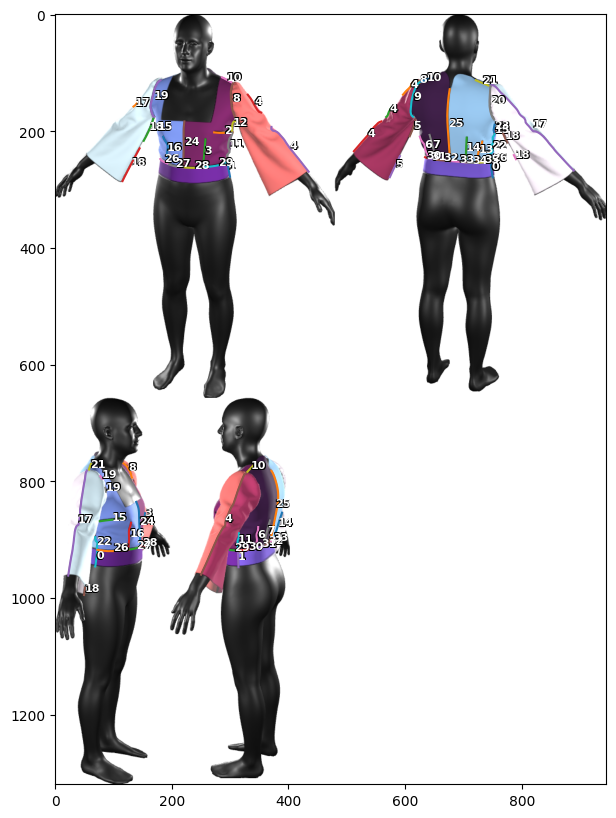

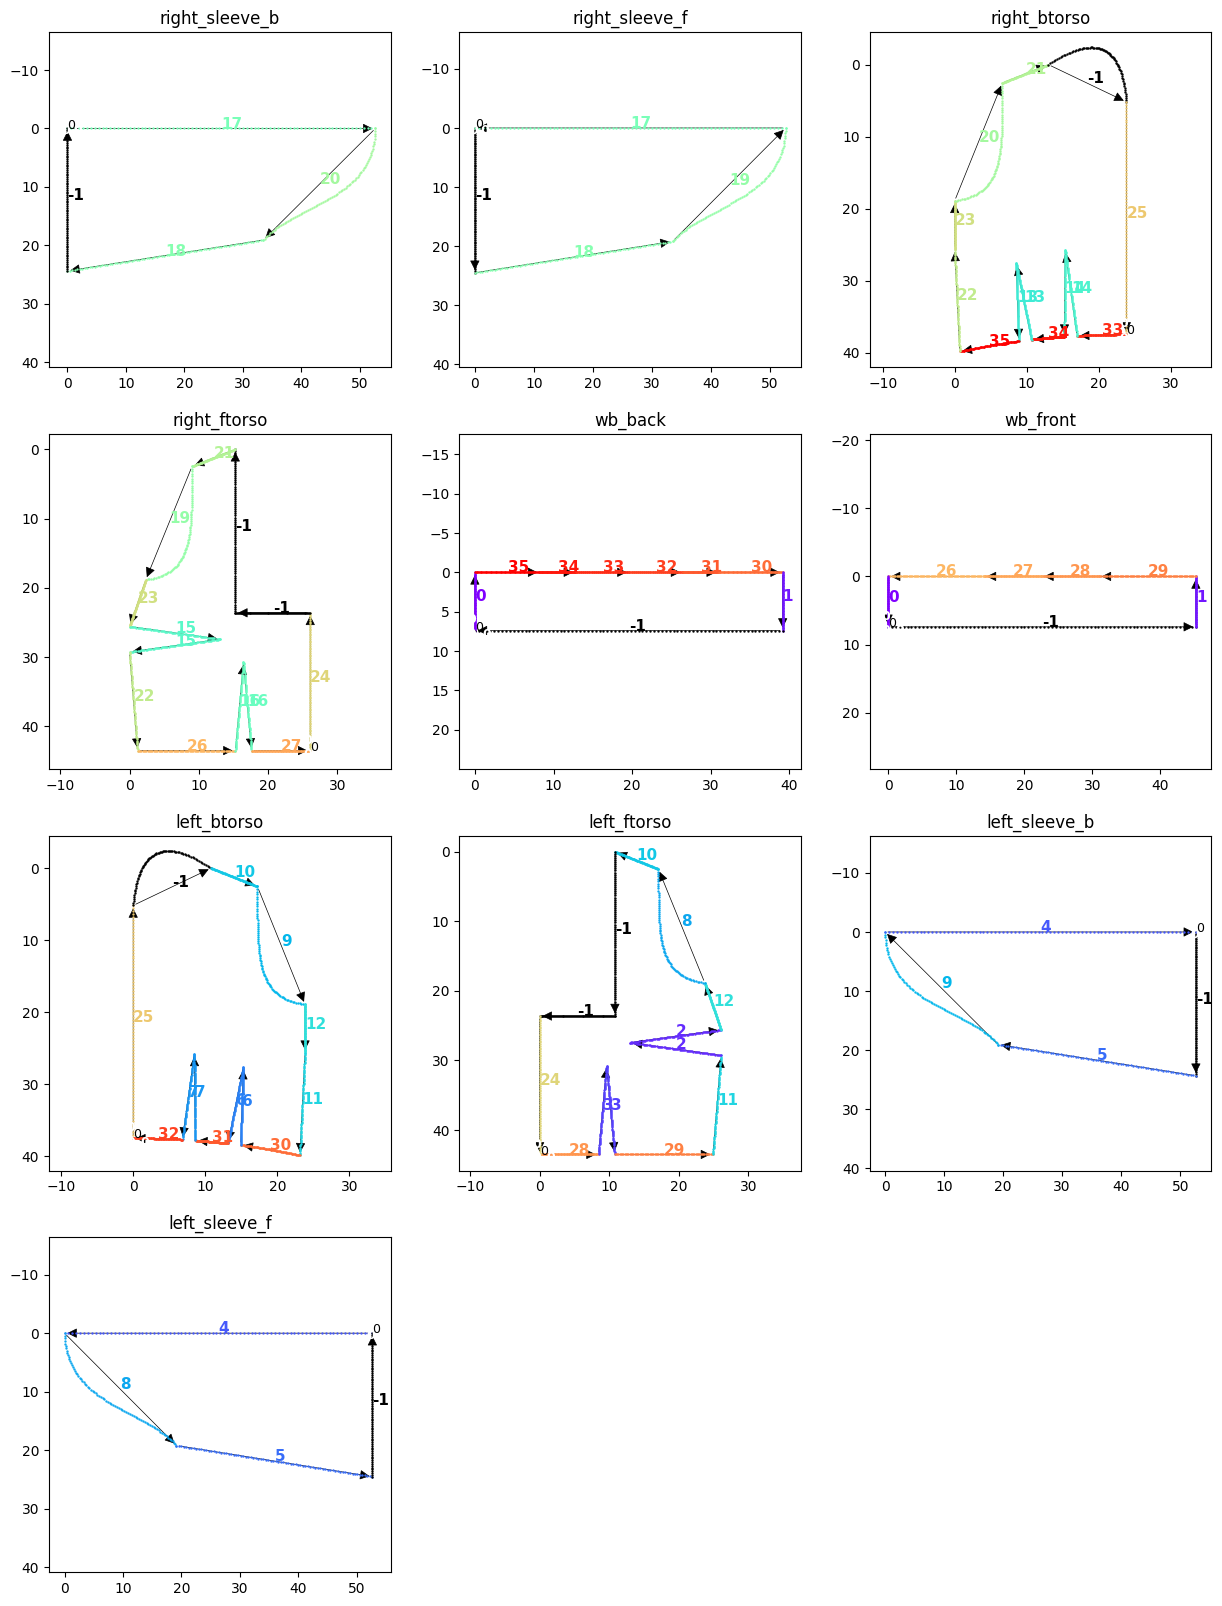

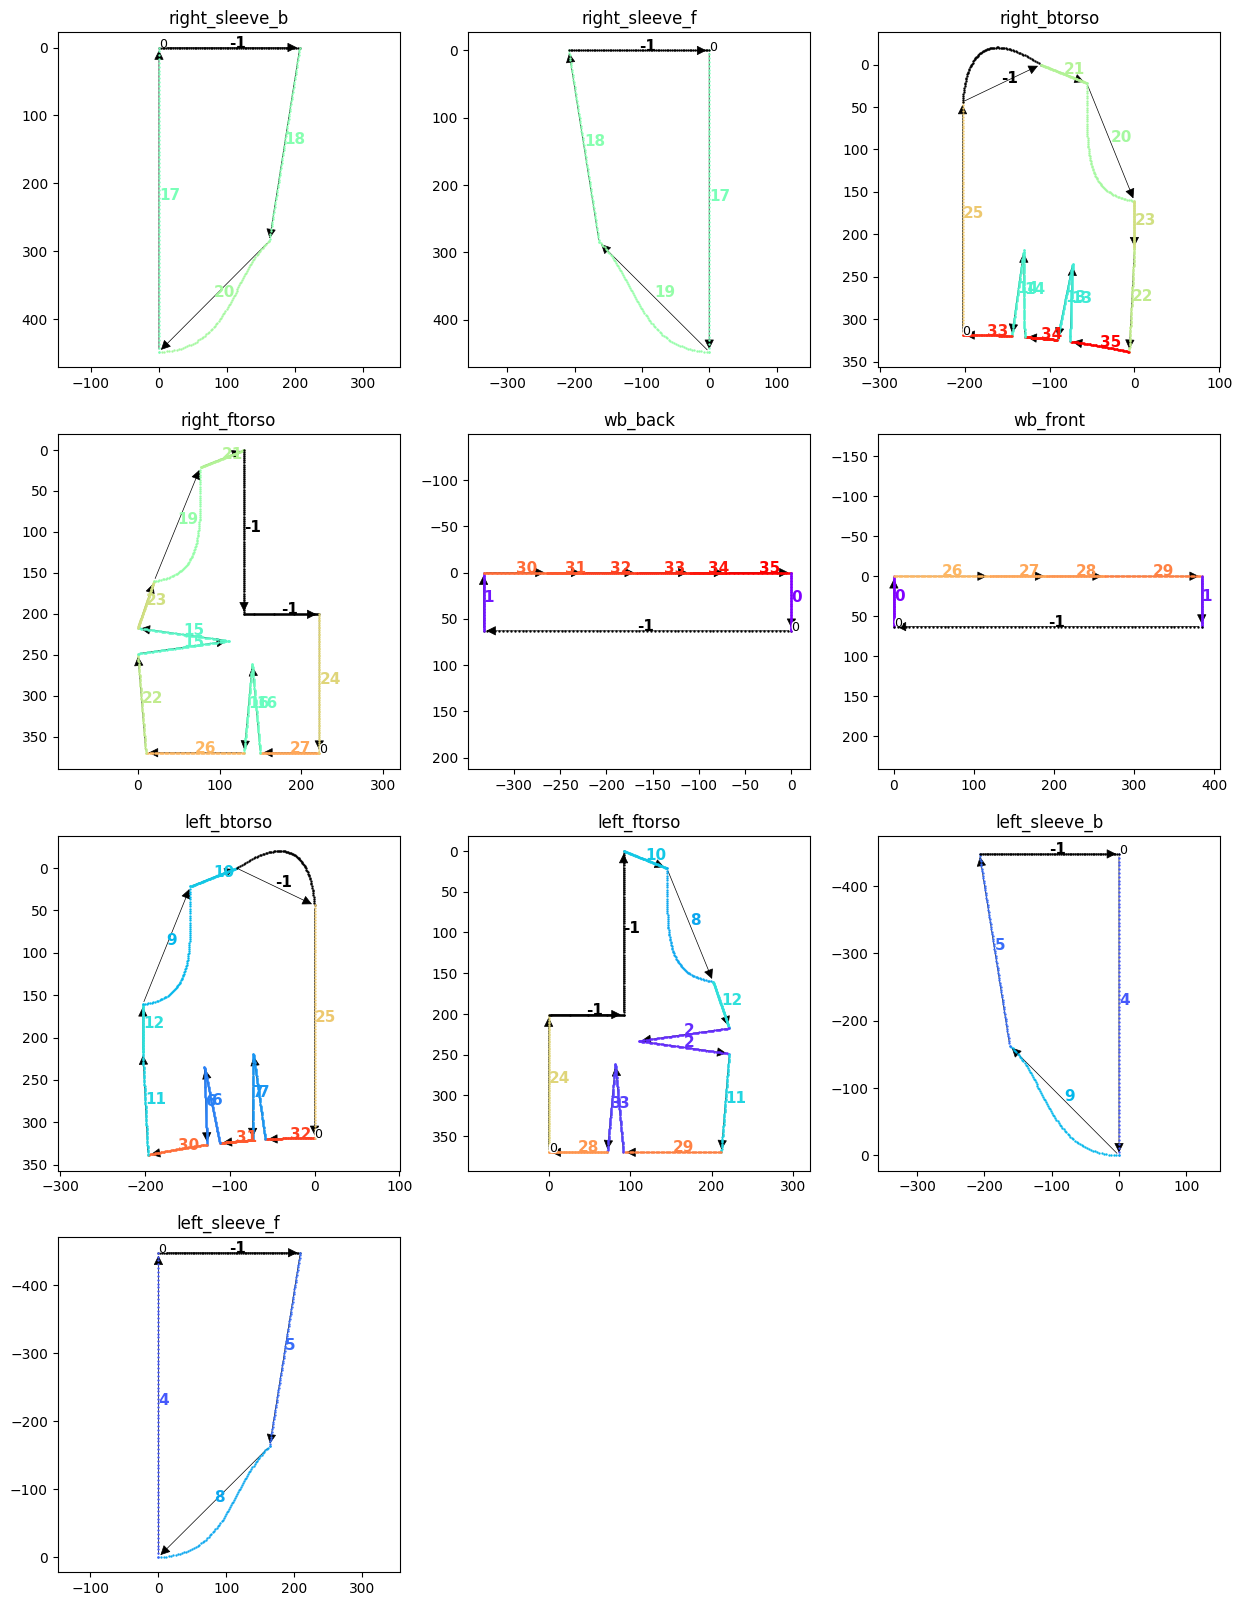

In [149]:
from pathlib import Path
import pandas as pd

garment_code_data_df = pd.read_csv(os.path.join(
    PYGARMENT_ROOT,
    "ANALYSIS_josef/Thinking/garment_code_data_meta_df_2.csv"
    # "garment_code_data_meta_df.csv"
))
garment_code_data_df["garment_path"].tolist()
garment_path = garment_code_data_df["garment_path"].tolist()[0]



panel_name_refine_map = {
    'left_collar_back'      : " collar left back",
    'left_collar_front'     : " collar left front",
    'right_collar_back'     : " collar right back",
    'right_collar_front'    : " collar right front",
    'left_hood'             : " hood left",
    'right_hood'            : " hood right",
    'pant_b_l'              : " pant left back",
    'pant_b_r'              : " pant right back",
    'pant_f_l'              : " pant left front",
    'pant_f_r'              : " pant right front",
    'pant_l_cuff_b'         : " pant cuff left back",
    'pant_l_cuff_f'         : " pant cuff left front",
    'pant_l_cuff_skirt_b'   : " pant cuff skirt left back",
    'pant_l_cuff_skirt_f'   : " pant cuff skirt left front",
    'pant_r_cuff_b'         : " pant cuff right back",
    'pant_r_cuff_f'         : " pant cuff right front",
    'pant_r_cuff_skirt_b'   : " pant cuff skirt right back",
    'pant_r_cuff_skirt_f'   : " pant cuff skirt right front",
    'left_btorso'           : " torso left back",
    'left_ftorso'           : " torso left front",
    'right_btorso'          : " torso right back",
    'right_ftorso'          : " torso right front",
    'left_sleeve_b'         : " sleeve left back",
    'left_sleeve_f'         : " sleeve left front",
    'skirt_back'            : " skirt back",
    'skirt_front'           : " skirt front",
    'right_sleeve_b'        : " sleeve right back",
    'right_sleeve_f'        : " sleeve right front",
    'sl_left_cuff_b'        : " sleeve cuff left back",
    'sl_left_cuff_f'        : " sleeve cuff left front",
    'sl_left_cuff_skirt_b'  : " sleeve cuff skirt left back",
    'sl_left_cuff_skirt_f'  : " sleeve cuff skirt left front",
    'sl_right_cuff_b'       : " sleeve cuff right back",
    'sl_right_cuff_f'       : " sleeve cuff right front",
    'sl_right_cuff_skirt_b' : " sleeve cuff skirt right back",
    'sl_right_cuff_skirt_f' : " sleeve cuff skirt right front",
    'wb_back'               : " waist band back",
    'wb_front'              : " waist band front",
}
side_list = get_poc_dataset_view_name_list()



fabric_uuid_set= set()
fabric_uuid = get_unique_random_string(fabric_uuid_set)
fabric_uuid_set.add(fabric_uuid)
random_hexa_code = generate_random_hex()


# ================================
IDX = random.randint(0, len(garment_code_data_df) - 1)
# ================================

print(IDX)
garment_path = os.path.join(
    DATASET_ROOT,
    "GarmentCodeData_v2",
    garment_code_data_df["garment_path"].tolist()[IDX]
)
print(garment_path)

garment_id = os.path.basename(garment_path)

view_label_dict, sewing_pattern, (box_mesh, panel_vertex_mask_dict) = read_poc_datapoint(
    garment_path, side_list, panel_name_refine_map
)


# < JUST VIS
n_side    = 4 # random.randint(2, 4) 
sampled_side_list = random.sample(side_list, n_side)
combined_label = combine_images_and_labels(
    list(map(lambda x: view_label_dict[x], sampled_side_list)),
    sewing_pattern,
)
plt.figure(figsize=(10, 10))
plt.imshow(combined_label.img)
for seam_line_dict in combined_label.seam_line_dict_list :
    for seam_line_idx, seam_line in seam_line_dict.items() :
        for segment_idx, segment in enumerate(seam_line.segment_vert_pos_arr_list) :
            plt.plot(segment[:, 0],segment[:, 1])
            text_obj = plt.annotate(
                f"{seam_line_idx}",
                (segment[:, 0].mean(), segment[:, 1].mean()),
                fontsize=8, color="white", fontweight="bold"
            )
            for dx, dy in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
                plt.annotate(
                    f"{seam_line_idx}",
                    (segment[:, 0].mean() + dx, segment[:, 1].mean() + dy),
                    fontsize=8, fontweight="bold",
                    zorder=text_obj.zorder - 1
                )
plt.show()
# > JUST VIS

panel_center_point_dict = {}
for k in panel_vertex_mask_dict.keys():
    if len(panel_vertex_mask_dict[k]) > 0:  # panel_vertex_mask_dict[k]가 비어 있지 않은지 확인
        panel_center_point_dict[k] = np.mean(box_mesh.vertices[panel_vertex_mask_dict[k]], axis=0)
    else:
        panel_center_point_dict[k] = np.nan  # 빈 배열이면 NaN 또는 다른 적절한 값으로 설정

garment_data = {
    "FabricList": [],
    "GradingRuleTableList": [],
    "PatternList": [],
    "SymmetricDataList": [],
    "InstanceDataList": [],
    "SeamLinePairGroupList": [],
}

sewing_pattern.draw()
plt.show()
 
for panel_name, svg_panel in sewing_pattern.panel_dict.items() :
    svg_panel.approximate_quadratic_bezier_with_cubic_bezier(VIS = False)
    svg_panel.approximate_arc_with_cubic_bezier(VIS = False)
    svg_panel.scale(8.5)

    if "sleeve" in panel_name :
        if "left" in panel_name :
            sewing_pattern.panel_dict[panel_name].rotate_clockwise(-90)
        if "right" in panel_name :
            sewing_pattern.panel_dict[panel_name].rotate_clockwise(90)
    refined_panel_name = sewing_pattern.panel_name_refine_map[panel_name] if panel_name in panel_name_refine_map else panel_name
    if "back" in refined_panel_name :
        sewing_pattern.mirror_panel_horizontally(panel_name)
    if sewing_pattern.panel_dict[panel_name].is_clockwise() != True :
        sewing_pattern.reverse_panel_path(panel_name)
    
    panel_batch_point = matching_point(
        panel_center_point_dict[panel_name]
    )

    panel_data_json = {
        "Name": f"{garment_id}_{panel_name}", # garment_id 추가함.
        "fGrainlineAngle": 0.0,
        "ID": f"{garment_id}_{panel_name}", # garment_id 추가함.
        "strSuperImposeSide": "None",
        "CurrentFabricUUID": fabric_uuid,
        "IsClosed": False,
        "InternalLineList": [],
        "ButtonHeadList": [],
        "ButtonHoleList": [],
        "AnnotationList": [],
        "NotchList": [],
        "IsHalfSymmetric": False,
        "ShapeInfo": {
            "IsSlashed": False,
            "LineList": [],
            "HalfSymmetryPointIDMap": {},
            "HalfSymmetryLineIDMap": {}
        },
        "ArrangementPointDataMap": {
                "PointName": panel_batch_point,
                "fOffSetX": 0.0,
                "fOffSetY": 0.05,
                "fAngle": 180.0
        }
    }
    # InstanceDataList에 json에 추가
    instance_data = {
        "OriginPatternID": panel_name,  # 패널 이름을 OriginPatternID로 사용
        "InstancePatternIDArray": []   # 빈 리스트로 추가
    }
    
    garment_data["InstanceDataList"].append(instance_data)
    
    coordinate_id_map = {}
    for edge_idx, edge in enumerate(svg_panel.svg_path):
        line_id = f"{panel_name}_edge_{edge_idx}"
        point_list = [] 
        
        if isinstance(edge, svgpath.CubicBezier):
            point_type_list = ["Straight", "Bezier Curve", "Bezier Curve", "Straight"]
            attribute_list = ["start", "control1", "control2", "end"]
        elif isinstance(edge, svgpath.Line):
            point_type_list = ["Straight", "Straight"]
            attribute_list = ["start", "end"]
        else :
            raise ValueError(f"Unknown edge type: {type(edge)}")
        
        for point_type, attribute in zip(point_type_list, attribute_list) :
            x = getattr(edge, attribute).real
            y = getattr(edge, attribute).imag
            key = (x, y)
            if key not in coordinate_id_map:
                coordinate_id_map[key] = f"{panel_name}_point_{len(coordinate_id_map)}"
            point_id = coordinate_id_map[key]
            point_list.append({
                "ID": point_id, 
                "PointType": point_type,
                "Position": {"x": x, "y": y},
                "GradingRuleID": -1
            })
            
        line = {"ID": line_id, "PointList": point_list}
        panel_data_json["ShapeInfo"]["LineList"].append(line)
                
    garment_data["PatternList"].append(panel_data_json)
    # offset_edges_by_panel = extract_internal_offset_edges_by_segment(
    #     panel_data, offset_dist= -2.0
    # )
    # internal_line_list = []
    # internal_coordinate_id_map = {}  # 내부 포인트 좌표와 ID를 매핑하기 위한 딕셔너리
    # internal_point_counter = 0
    # internal_line_counter = 0
    #print(offset_edges_by_panel)
    # line_list = [] #246에 있던걸 여기로 옮겨봄.
    # for panel_idx, edge_panel in enumerate(offset_edges_by_panel):
    #     #line_list = [] 
    #     # 각 panel의 각 엣지(라인)에 대해 처리
    #     pt_list = []
    #     pts = edge_panel['offset_points']
    #     if not pts:
    #         continue
    #     if edge_panel['type'] == 'Straight':
    #         # Straight의 경우 모든 점의 PointType은 "Straight"
    #         for p in pts:
    #             coord = (p[0], p[1])
    #             if coord not in internal_coordinate_id_map:
    #                 internal_coordinate_id_map[coord] = f"{panel_name}_internal_point_{internal_point_counter}"
    #                 internal_point_counter += 1
    #             point_id = internal_coordinate_id_map[coord]
    #             point_dict = {
    #                 "ID": point_id,
    #                 "PointType": "Straight",
    #                 "Position": {"x": p[0], "y": p[1]},
    #                 "GradingRuleID": -1
    #             }
    #             pt_list.append(point_dict)
    #     elif edge_panel['type'] == 'Bezier':
    #         # Bezier의 경우, 첫점과 마지막 점은 "Straight", 중간은 "Polyline"
    #         for i, p in enumerate(pts):
    #             point_type = "Straight" if (i == 0 or i == (len(pts) - 1)) else "Polyline"
    #             coord = (p[0], p[1])
    #             if coord not in internal_coordinate_id_map:
    #                 internal_coordinate_id_map[coord] = f"{panel_name}_internal_point_{internal_point_counter}"
    #                 internal_point_counter += 1
    #             point_id = internal_coordinate_id_map[coord]
    #             point_dict = {
    #                 "ID": point_id,
    #                 "PointType": point_type,
    #                 "Position": {"x": p[0], "y": p[1]},
    #                 "GradingRuleID": -1
    #             }
    #             pt_list.append(point_dict)
    #     else:
    #         continue

        # line_dict = {
        #     "ID": f"{panel_name}_internal_line_{internal_line_counter}",
        #     "PointList": pt_list
        # }
        # line_list.append(line_dict)
        # internal_line_counter += 1

        # 예제에서는 첫번째 패널은 닫힌 모양(closed), 두번째는 열린 모양(open)으로 가정
    # panel_dict = {
    #     "LineList": line_list,
    #     "ID": f"{panel_name}_internal_line",
    #     "ShapeType": 1, #if panel_idx == 0 else 2,
    #     "IsClosed": True, #if panel_idx == 0 else False,
    #     "FoldData": {
    #         "iAngle": 90,
    #         "iStrength": 5,
    #         "bRenderFolded": False
    #     }
    # }
    
    # internal_line_list.append(panel_dict)

    # panel_data_json["InternalLineList"] = internal_line_list

sewing_pattern.draw()
plt.show()



garment_data["SeamLinePairGroupList"] = []
fabric_group = {
    "FabricName" : "Default Fabric",
    "FabricType" : "None",
    "FabricContent" : "None",
    "strBaseColorHexCode" : random_hexa_code,
    "FabricUUID" : fabric_uuid
    }
# SeamLinePairGroupList 생성 루프

for stch_idx, stch_info in enumerate(sewing_pattern.stitch_dict.items()) :
# for idx, value in enumerate(stitch_dict.values()):
    # "Name" 생성
    group_name = f"{garment_id}_SeamLineGroup_{stch_idx}"

    # value에서 첫 번째와 두 번째 ShapeID 정보 추출
    
    # first_info = value[0]
    # second_info = value[1]
        
    # 정보 저장
    first_panel = stch_info.panel_0
    first_edge  = stch_info.edge_0
    first_shape_id = f"{garment_id}_{first_panel}"
    fstt = sewing_pattern.panel_dict[first_panel].normalized_edge_stt
    fend = sewing_pattern.panel_dict[first_panel].normalized_edge_end
    
    second_panel = stch_info.panel_1
    second_edge = stch_info.edge_1 
    second_shape_id = f"{garment_id}_{second_panel}"
    sstt = sewing_pattern.panel_dict[second_panel].normalized_edge_stt
    send = sewing_pattern.panel_dict[second_panel].normalized_edge_end
    
    first_direction = True
    second_direction = False
    
    # direction 결정 뒤에 정해 놓는 fstart, fend
    if first_direction == False:
        first_fstart, first_fend = first_fstart_fend["fend"], first_fstart_fend["fstart"]
    else:
        first_fstart, first_fend = first_fstart_fend["fstart"], first_fstart_fend["fend"]        
        
    if second_direction == False:
        second_fstart, second_fend = second_fstart_fend["fend"], second_fstart_fend["fstart"]
    else:
        second_fstart, second_fend = second_fstart_fend["fstart"], second_fstart_fend["fend"]
    

    # JSON 구조 생성
    seam_line_pair_group = {
        "Name": group_name,
        "bIsTurned": False,
        "PairList": [
            {
                "First": {
                    "ShapeID": first_shape_id,
                    "LengthParam": {
                        "fStart": first_fstart,
                        "fEnd": first_fend
                    },
                    "Direction": first_direction
                },
                "Second": {
                    "ShapeID": second_shape_id,
                    "LengthParam": {
                        "fStart": second_fstart,
                        "fEnd": second_fend
                    },
                    "Direction": second_direction 
                }
            }
        ],
        "FoldData": {
            "iAngle": 270,
            "iStrength": 5
        }
    }

    # SeamLinePairGroupList에 추가
    garment_data["SeamLinePairGroupList"].append(seam_line_pair_group)

garment_data["FabricList"].append(fabric_group)    

panel_index_mapping = {name: idx for idx, name in enumerate(panel_names)}

stitch_info = convert_stitch_dict(stitch_dict, panel_index_mapping)

panel_dict = {"panel_names" : panel_names}
DIR = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/ADD_INTERNAL_LINE_DATA"
DIR_NAME = f"{path_split[-3]}_{garment_id}"
JSON_PATH = os.path.join(DIR, DIR_NAME)
os.makedirs(os.path.join(DIR, DIR_NAME), exist_ok=True)
# CLO JSON DATA FILE
json_output_file = f"{JSON_PATH}/Clo_Garment_{path_split[-3]}_{garment_id}.json"
# STITCH DATA FILE
stitch_output_file = f"{JSON_PATH}/Clo_Stitch_{path_split[-3]}_{garment_id}.json"
panel_name_file = f"{JSON_PATH}/Clo_Panel_Name_{path_split[-3]}_{garment_id}.json"


In [158]:
svg_panel.svg_path[2].__dict__

{'start': np.complex128(163.39442461879935-162.78949846065996j),
 'control1': np.complex128(108.80739830551957-114.74698930627103j),
 'control2': np.complex128(104.28173613913626-2.2563383965190624j),
 'end': np.complex128(0j),
 '_length_info': {'length': None,
  'bpoints': None,
  'error': None,
  'min_depth': None}}

In [160]:
getattr(svg_panel.svg_path[2], "start")

np.complex128(163.39442461879935-162.78949846065996j)

In [159]:
svg_panel.svg_path[1].__dict__

{'start': np.complex128(208.62892086895192-447.58973870957095j),
 'end': np.complex128(163.39442461879938-162.78949846065998j)}

In [78]:
from pathlib import Path
import pandas as pd




panel_name_refine_map = {
    'left_collar_back'      : " collar left back",
    'left_collar_front'     : " collar left front",
    'right_collar_back'     : " collar right back",
    'right_collar_front'    : " collar right front",
    'left_hood'             : " hood left",
    'right_hood'            : " hood right",
    'pant_b_l'              : " pant left back",
    'pant_b_r'              : " pant right back",
    'pant_f_l'              : " pant left front",
    'pant_f_r'              : " pant right front",
    'pant_l_cuff_b'         : " pant cuff left back",
    'pant_l_cuff_f'         : " pant cuff left front",
    'pant_l_cuff_skirt_b'   : " pant cuff skirt left back",
    'pant_l_cuff_skirt_f'   : " pant cuff skirt left front",
    'pant_r_cuff_b'         : " pant cuff right back",
    'pant_r_cuff_f'         : " pant cuff right front",
    'pant_r_cuff_skirt_b'   : " pant cuff skirt right back",
    'pant_r_cuff_skirt_f'   : " pant cuff skirt right front",
    'left_btorso'           : " torso left back",
    'left_ftorso'           : " torso left front",
    'right_btorso'          : " torso right back",
    'right_ftorso'          : " torso right front",
    'left_sleeve_b'         : " sleeve left back",
    'left_sleeve_f'         : " sleeve left front",
    'skirt_back'            : " skirt back",
    'skirt_front'           : " skirt front",
    'right_sleeve_b'        : " sleeve right back",
    'right_sleeve_f'        : " sleeve right front",
    'sl_left_cuff_b'        : " sleeve cuff left back",
    'sl_left_cuff_f'        : " sleeve cuff left front",
    'sl_left_cuff_skirt_b'  : " sleeve cuff skirt left back",
    'sl_left_cuff_skirt_f'  : " sleeve cuff skirt left front",
    'sl_right_cuff_b'       : " sleeve cuff right back",
    'sl_right_cuff_f'       : " sleeve cuff right front",
    'sl_right_cuff_skirt_b' : " sleeve cuff skirt right back",
    'sl_right_cuff_skirt_f' : " sleeve cuff skirt right front",
    'wb_back'               : " waist band back",
    'wb_front'              : " waist band front",
}

side_list = get_poc_dataset_view_name_list()

garment_code_data_df = pd.read_csv(os.path.join(
    PYGARMENT_ROOT,
    "ANALYSIS_josef/Thinking/garment_code_data_meta_df_2.csv"
))
garment_code_data_df["garment_path"].tolist()


# ================================
IDX = 0
# ================================


garment_path = os.path.join(DATASET_ROOT, "GarmentCodeData_v2", garment_code_data_df["garment_path"].tolist()[IDX])

fabric_uuid_set= set()
fabric_uuid = get_unique_random_string(unique_str_set)
fabric_uuid_set.add(fabric_uuid)

random_hexa_code = generate_random_hex()
 
view_label_dict, sewing_pattern, (box_mesh, panel_vertex_mask_dict) = read_poc_datapoint(
    garment_path, side_list, panel_name_refine_map
)

panel_center_point_dict = {}
for k in panel_vertex_mask_dict.keys():
    if len(panel_vertex_mask_dict[k]) > 0:  # panel_vertex_mask_dict[k]가 비어 있지 않은지 확인
        panel_center_point_dict[k] = np.mean(box_mesh.vertices[panel_vertex_mask_dict[k]], axis=0)
    else:
        panel_center_point_dict[k] = np.nan  # 빈 배열이면 NaN 또는 다른 적절한 값으로 설정

panel_fstart_fend_info = {}

panel_name_list = list(sewing_pattern.panel_dict.keys())
for panel_name in panel_name_list:
    path = panel_svg_path_dict[panel_name][0]  # 패널에 해당하는 경로 정보 가져오기
    fstart_fend_results = calculate_fstart_fend(path) # TODO: 2024.01.19 14:33 panel_name 넣기
    panel_fstart_fend_info[panel_name] = fstart_fend_results  # 결과를 딕셔너리에 저장


['sl_right_cuff_skirt_b',
 'sl_right_cuff_skirt_f',
 'right_sleeve_b',
 'right_sleeve_f',
 'right_btorso',
 'right_ftorso',
 'skirt_back',
 'skirt_front',
 'left_btorso',
 'left_ftorso',
 'left_sleeve_b',
 'left_sleeve_f',
 'sl_left_cuff_skirt_b',
 'sl_left_cuff_skirt_f']

In [74]:
panel_vertex_mask_dict.keys()

dict_keys(['sl_right_cuff_skirt_b', 'sl_right_cuff_skirt_f', 'right_sleeve_b', 'right_sleeve_f', 'right_btorso', 'right_ftorso', 'skirt_back', 'skirt_front', 'left_btorso', 'left_ftorso', 'left_sleeve_b', 'left_sleeve_f', 'sl_left_cuff_skirt_b', 'sl_left_cuff_skirt_f'])

In [77]:
sewing_pattern.panel_dict.keys() == panel_vertex_mask_dict.keys()

True

### Legacy

In [52]:
# Internal Line 그리기 위해서 사용하는 함수.
import math
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon, LineString

##############################################################################
# 1. Cubic Bézier 곡선을 폴리라인으로 근사하는 함수
##############################################################################
def approximate_cubic_bezier(p0, c1, c2, p3, steps=10):
    """
    3차 베지어 곡선을 'steps' 개로 분할하여 (x, y) 좌표 리스트를 리턴.
    """
    points = []
    for i in range(steps+1):
        t = i / steps
        x = (1 - t)**3 * p0[0] + 3*(1 - t)**2 * t * c1[0] + 3*(1 - t)*t**2 * c2[0] + t**3 * p3[0]
        y = (1 - t)**3 * p0[1] + 3*(1 - t)**2 * t * c1[1] + 3*(1 - t)*t**2 * c2[1] + t**3 * p3[1]
        points.append((x, y))
    return points

##############################################################################
# 2. 에지 리스트로부터 패널 폴리라인 만들기 (전체 외곽선용)
##############################################################################
def build_polyline_from_edges(edges):
    """
    edges: [
      [(x1, y1, 'Straight'), (x2, y2, 'Straight')],
      [(x3, y3, 'Straight'), (cx1, cy1, 'Bezier Curve'), (cx2, cy2, 'Bezier Curve'), (x4, y4, 'Straight')],
      ...
    ]
    """
    all_points = []
    for segment in edges:
        n = len(segment)
        if n == 2:
            # 직선 세그먼트
            p0 = (segment['points'][0][0], segment['points'][0][1])
            p1 = (segment['points'][1][0], segment['points'][1][1])
            if not all_points:
                all_points.append(p0)
            else:
                if all_points[-1] != p0:
                    all_points.append(p0)
            all_points.append(p1)
        elif n == 4:
            # 3차 베지어 세그먼트
            p0 = (segment['points'][0][0], segment['points'][0][1])
            c1 = (segment['points'][1][0], segment['points'][1][1])
            c2 = (segment['points'][2][0], segment['points'][2][1])
            p3 = (segment['points'][3][0], segment['points'][3][1])
            curve_points = approximate_cubic_bezier(p0, c1, c2, p3, steps=10)
            if not all_points:
                all_points.extend(curve_points)
            else:
                if all_points[-1] == curve_points[0]:
                    all_points.extend(curve_points[1:])
                else:
                    all_points.extend(curve_points)
        else:
            raise ValueError("세그먼트 점 개수가 2(직선) 또는 4(베지어)만 지원합니다.")
    if all_points and (all_points[0] != all_points[-1]):
        all_points.append(all_points[0])
    return all_points

##############################################################################
# 3. 다각형의 외곽선 방향(orientation)을 구하는 헬퍼 함수 (shoelace 공식)
##############################################################################
def compute_polygon_orientation(points):
    """
    points: (x, y) 좌표 리스트 (폐곡선일 경우 마지막 점이 첫 점과 동일)
    리턴: 'ccw' (반시계방향) 또는 'cw' (시계방향)
    """
    area = 0
    # 마지막 중복점은 제외
    for i in range(len(points)-1):
        x0, y0 = points[i]
        x1, y1 = points[i+1]
        area += x0 * y1 - x1 * y0
    return 'ccw' if area > 0 else 'cw'

##############################################################################
# 4. 두 선분(무한 직선)의 교차점을 구하는 헬퍼 함수
##############################################################################
def line_intersection(p1, p2, p3, p4):
    """
    p1, p2: 첫 번째 직선을 정의하는 두 점
    p3, p4: 두 번째 직선을 정의하는 두 점
    리턴: 두 직선의 교차점 (x, y) 또는 평행하면 None
    """
    x1, y1 = p1; x2, y2 = p2
    x3, y3 = p3; x4, y4 = p4
    denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(denom) < 1e-10:
        return None  # 평행
    intersect_x = ((x1*y2 - y1*x2) * (x3 - x4) - (x1 - x2) * (x3*y4 - y3*x4)) / denom
    intersect_y = ((x1*y2 - y1*x2) * (y3 - y4) - (y1 - y2) * (x3*y4 - y3*x4)) / denom
    return (intersect_x, intersect_y)

##############################################################################
# 5. 각 패널의 원래 엣지(세그먼트)를 개별적으로 오프셋한 후, 
#    오프셋 결과와 함께 해당 엣지 유형(Bezier/Straight)도 저장하고,
#    인접 엣지의 교차점을 계산해 시작/끝점이 연결되도록 보정하는 함수
##############################################################################

def extract_internal_offset_edges_by_segment(panel_edge_list, offset_dist):    
    """
    panel_edge_list = [{ "start_x": a, "start_y": b, "end_x": c, "end_y": d, "type": "Straight"},
                       { "start_x": a, "start_y": b, "control1_x": e, "control1_y": f, "control2_x": g, "control2_y": h, "end_x": c, "end_y": d, "type": "Bezier Curve"}]
    """
    """
    리턴: 각 패널별로 원래의 각 엣지에 대해,
           {'type': 'Straight' 또는 'Bezier', 'offset_points': [(x, y), ...]} 형태의 리스트
           단, 인접 엣지간의 offset 결과가 교차점을 기준으로 연결됩니다.
    """
    panel_offset_edges = []
    original_edges = []
    # 원래 엣지를 분리 (타입 정보 포함)
    for seg in panel_edge_list:
        if seg["type"] == "Bezier Curve":
            p0 = (seg["start_x"], seg["start_y"])
            c1 = (seg["control1_x"], seg["control1_y"])
            c2 = (seg["control2_x"], seg["control2_y"])
            p3 = (seg["end_x"], seg["end_y"])
            bezier_points = approximate_cubic_bezier(p0, c1, c2, p3)
            original_edges.append({'points': bezier_points, 'type': 'Bezier'})
        elif seg["type"] == "Straight":
            p0 = (seg["start_x"], seg["start_y"])
            p1 = (seg["end_x"], seg["end_y"])
            original_edges.append({'points': [p0, p1], 'type': 'Straight'})
        else:
            pass
            
    # 전체 외곽선으로부터 다각형 방향(orientation) 구하기
    ### 여기부터 변환 필요.
    outline_points = build_polyline_from_edges(original_edges)
    orientation = compute_polygon_orientation(outline_points)
    
    # 각 엣지별 오프셋 계산 (LineString.parallel_offset 사용)
    panel_offset_edges = []
    for edge in original_edges:
        line = LineString(edge['points'])
        # **내부 오프셋: polygon 내부가 CCW이면 interior는 left, CW이면 interior는 right**
        if offset_dist < 0:
            side = 'left' if orientation == 'ccw' else 'right'
        else:
            side = 'right' if orientation == 'ccw' else 'left'
        try:
            offset_line = line.parallel_offset(abs(offset_dist), side=side, resolution=16)
        except Exception as e:
            offset_line = None
        offset_coords = []
        if offset_line is not None:
            if offset_line.is_empty:
                offset_coords = []
            elif offset_line.geom_type == 'LineString':
                offset_coords = list(offset_line.coords)
            elif offset_line.geom_type.startswith('Multi'):
                # MultiLineString: 가장 긴 부분 선택
                parts = list(offset_line)
                longest = max(parts, key=lambda ls: ls.length)
                offset_coords = list(longest.coords)
        panel_offset_edges.append({'type': edge['type'], 'offset_points': offset_coords})
    
    # 보정: 인접 엣지의 offset 결과가 만나도록 (연결된 start/end) 교차점을 계산
    n = len(panel_offset_edges)
    if n > 1:
        # 순환 구조라고 가정 (폐곡선)
        for i in range(n):
            curr_edge = panel_offset_edges[i]
            next_edge = panel_offset_edges[(i+1) % n]
            if not curr_edge['offset_points'] or not next_edge['offset_points']:
                continue
            curr_start = curr_edge['offset_points'][0]
            curr_end = curr_edge['offset_points'][-1]
            next_start = next_edge['offset_points'][0]
            next_end = next_edge['offset_points'][-1]
            inter = line_intersection(curr_start, curr_end, next_start, next_end)
            if inter is not None:
                curr_edge['offset_points'][-1] = inter
                next_edge['offset_points'][0] = inter
    
    # panel_offset_edges.append(panel_offset_edges) 이거 불필요
    return panel_offset_edges



In [53]:
import math
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon, LineString
from shapely.ops import unary_union

def approximate_cubic_bezier(p0, c1, c2, p3, steps=10):
    """
    3차 베지어 곡선을 'steps' 개로 분할하여 (x, y) 좌표 리스트를 리턴.
    """
    points = []
    for i in range(steps+1):
        t = i / steps
        x = (1 - t)**3 * p0[0] + 3*(1 - t)**2 * t * c1[0] + 3*(1 - t)*t**2 * c2[0] + t**3 * p3[0]
        y = (1 - t)**3 * p0[1] + 3*(1 - t)**2 * t * c1[1] + 3*(1 - t)*t**2 * c2[1] + t**3 * p3[1]
        points.append((x, y))
    return points

def build_polyline_from_edges(edges):
    """
    edges: [
      {'points': [(x1, y1), (x2, y2)], 'type': 'Straight'},
      {'points': [(x3, y3), (cx1, cy1), (cx2, cy2), (x4, y4)], 'type': 'Bezier'},
      ...
    ]
    -> polyline (폐곡선) 리턴
    """
    all_points = []
    for segment in edges:
        pts = segment['points']
        n = len(pts)
        if n == 2 and segment['type'] == 'Straight':
            p0 = pts[0]
            p1 = pts[1]
            if not all_points:
                all_points.append(p0)
            else:
                # 연속된 점이 중복되지 않도록 처리
                if all_points[-1] != p0:
                    all_points.append(p0)
            all_points.append(p1)

        elif n == 4 and segment['type'] == 'Bezier':
            p0, c1, c2, p3 = pts
            curve_points = approximate_cubic_bezier(p0, c1, c2, p3, steps=10)
            if not all_points:
                all_points.extend(curve_points)
            else:
                if all_points[-1] == curve_points[0]:
                    all_points.extend(curve_points[1:])
                else:
                    all_points.extend(curve_points)
        else:
            raise ValueError("지원하지 않는 세그먼트 형식이거나 점 개수가 잘못되었습니다.")

    # 폐곡선 처리
    if all_points and (all_points[0] != all_points[-1]):
        all_points.append(all_points[0])
    return all_points

def compute_polygon_orientation(points):
    """
    points: (x, y) 좌표 리스트 (폐곡선), shoelace 공식으로 방향 판별
    """
    area = 0
    for i in range(len(points)-1):
        x0, y0 = points[i]
        x1, y1 = points[i+1]
        area += x0 * y1 - x1 * y0
    return 'ccw' if area > 0 else 'cw'

def extract_internal_offset_edges_by_segment(panel_edge_list, offset_dist):
    """
    panel_edge_list = [
      {"start_x": a, "start_y": b, "end_x": c, "end_y": d, "type": "Straight"},
      {"start_x": a, "start_y": b, "control1_x": e, "control1_y": f,
       "control2_x": g, "control2_y": h, "end_x": c, "end_y": d,
       "type": "Bezier Curve"},
      ...
    ]
    -> 내부 오프셋 된 "Straight" 세그먼트 리스트로 리턴 (예: [{"type":"Straight", "offset_points":[(x,y), (x',y')]}, ...])
    """

    # 1) panel_edge_list를 내부적으로 처리하기 쉽도록 기존 포맷으로 변환
    original_edges = []
    for seg in panel_edge_list:
        if seg["type"] == "Bezier Curve":
            # Bezier
            p0 = (seg["start_x"], seg["start_y"])
            c1 = (seg["control1_x"], seg["control1_y"])
            c2 = (seg["control2_x"], seg["control2_y"])
            p3 = (seg["end_x"], seg["end_y"])
            original_edges.append({
                'points': [p0, c1, c2, p3],
                'type': 'Bezier'
            })
        elif seg["type"] == "Straight":
            # Straight
            p0 = (seg["start_x"], seg["start_y"])
            p1 = (seg["end_x"], seg["end_y"])
            original_edges.append({
                'points': [p0, p1],
                'type': 'Straight'
            })
        else:
            raise ValueError("알 수 없는 segment type")

    # 2) 전체 외곽선 polyline 구하기
    outline_points = build_polyline_from_edges(original_edges)
    if len(outline_points) < 4:
        return []  # 무효한 폴리곤이라면 빈 리스트
    
    orientation = compute_polygon_orientation(outline_points)

    # 3) Shapely Polygon 생성
    polygon = Polygon(outline_points)
    if not polygon.is_valid:
        # self-intersection 등이 있다면 unary_union 등을 써서 정리
        polygon = polygon.buffer(0)

    if polygon.is_empty:
        return []

    # 4) 내부 오프셋 (negative buffer)
    #    offset_dist가 음수이든 양수이든, 내부 오프셋은 실제로 "음수 거리"로 buffer
    internal_polygon = polygon.buffer(-abs(offset_dist), resolution=16, join_style=1)
    # join_style=1 (round), =2(mitre), =3(bevel)
    # 상황에 맞게 옵션 변경 가능

    # 5) MultiPolygon 처리 (여러 조각으로 분할되었을 경우)
    if internal_polygon.is_empty:
        return []
    if internal_polygon.geom_type == 'MultiPolygon':
        # 가장 큰 면적만 선택
        internal_polygon = max(internal_polygon.geoms, key=lambda a: a.area)

    if internal_polygon.is_empty or internal_polygon.geom_type != 'Polygon':
        return []

    # 6) 내부 오프셋 결과 폴리곤의 exterior(바깥 경계) 좌표 추출
    offset_coords = list(internal_polygon.exterior.coords)
    # Shapely가 마지막 점 = 첫 점 형태로 닫혀 있음
    # -> 필요에 따라 마지막 점을 제거하거나 그대로 사용

    if len(offset_coords) < 2:
        return []

    # 7) 반환 형식으로 가공: "Straight" 세그먼트 모음
    #    => 예: [{"type":"Straight", "offset_points":[(x0,y0),(x1,y1)]},
    #            {"type":"Straight", "offset_points":[(x1,y1),(x2,y2)]}, ...]
    panel_offset_edges = []
    for i in range(len(offset_coords) - 1):
        pA = offset_coords[i]
        pB = offset_coords[i+1]
        panel_offset_edges.append({
            "type": "Straight",
            "offset_points": [pA, pB]
        })

    # 폴리곤이 닫혀 있으므로, 마지막 세그먼트(끝->처음) 연결을 원하는 경우 추가
    # 필요하다면 아래 주석 해제
    """
    pLast = offset_coords[-1]
    pFirst = offset_coords[0]
    panel_offset_edges.append({
        "type": "Straight",
        "offset_points": [pLast, pFirst]
    })
    """

    return panel_offset_edges

In [54]:
import os, sys

sys.path.append(os.path.dirname(os.getcwd()))

from env_constants import PYGARMENT_ROOT, DATASET_ROOT

In [55]:

GARMENT_ROOT_PATH = os.path.join(DATASET_ROOT, "GarmentCodeData_v2")
BODY_ROOT_PATH = os.path.join(DATASET_ROOT, "body_mesh")
MEAN_ALL_BODY_PATH = os.path.join(DATASET_ROOT, "neutral_body/mean_all.obj")

# random choice two number
BODY_TYPE = "default_body"
    
default_body_mesh = trimesh.load(MEAN_ALL_BODY_PATH)

garment_path_list = sorted(list(filter(
    os.path.isdir,
    glob(os.path.join(GARMENT_ROOT_PATH, "*", BODY_TYPE, "*"))
)))
len(garment_path_list)


132670

In [56]:
#len(garment_path_list[0])
garment_path = garment_path_list[0]
path_split= garment_path.split(os.sep)
garment_id= os.path.basename(garment_path)
print()


In [165]:
sewing_pattern.stitch_dict[0].panel_0

'wb_front'

In [37]:
# 임의로 5개만 테스트
generated = set()

#for IDX in tqdm(range(1)):
# for IDX in tqdm(range(len(garment_path_list))):  
for IDX in tqdm(range(1)) :
    # random Fabric UUID 생성
    fabric_uuid = get_unique_random_string(generated)    
    random_hexa_code = generate_random_hex()
    garment_path = garment_path_list[IDX]
    path_split= garment_path.split(os.sep)
    garment_id= os.path.basename(garment_path)
    
    SPEC_FILE_PATH = os.path.join(garment_path,  f"{garment_id}_specification.json")
    pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)
    
    drawn_pattern_list = list(map(
        lambda pannel_name : pattern._draw_a_panel(
            pannel_name, apply_transform=False, fill=True
        ),
        pattern.panel_order()
    ))
    
    panel_svg_path_dict = {
        panel_name : pattern._draw_a_panel(
            panel_name, apply_transform=False, fill=True
        )
        for panel_name in pattern.panel_order()
    }

    stitch_dict = {
        i : v for i, v in enumerate(pattern.pattern['stitches'])
    }

    # json의 rotation translation 추출을 위한 정보
    spec = load_json_file(SPEC_FILE_PATH)
    """
    # TODO: 2025.02.05 패널 중심점 대신 Mean Point 사용한 버전
    """
### 여기부터
    box_mesh = trimesh.load_mesh(
        os.path.join(garment_path, f"{garment_id}_boxmesh.ply"),
        process=False
    )

    idx_convert_map = np.array(v_id_map(box_mesh.vertices))


    # Read Vertex Label
    with open(os.path.join(garment_path, f"{garment_id}_sim_segmentation.txt"), "r") as f:
        segmentation = list(map(
            lambda x : x.strip(),
            f.readlines()
        ))
    # stitch_vertex_mask_dict = {}
    # for k in stitch_dict.keys():
    #     raw_mask = list(map(
    #         lambda x : True if f"stitch_{k}" in x.split(",") else False,
    #         segmentation
    #     ))
    #     base_mask = np.array(list(map(
    #         lambda idx : True if raw_mask[idx] else False,
    #         idx_convert_map
    #     )))
    #     stitch_vertex_mask_dict[k] = base_mask

    panel_vertex_mask_dict = {}
    for k in panel_svg_path_dict.keys():
        raw_mask = list(map(
            lambda x : True if x.startswith(k) else False,
            segmentation
        ))
        panel_vertex_mask_dict[k] = np.array(list(map(
            lambda idx : True if raw_mask[idx] else False,
            idx_convert_map
        )))

    panel_center_point_dict = {}
    for k in panel_vertex_mask_dict.keys():
        if len(panel_vertex_mask_dict[k]) > 0:  # panel_vertex_mask_dict[k]가 비어 있지 않은지 확인
            panel_center_point_dict[k] = np.mean(box_mesh.vertices[panel_vertex_mask_dict[k]], axis=0)
        else:
            panel_center_point_dict[k] = np.nan  # 빈 배열이면 NaN 또는 다른 적절한 값으로 설정
        
        
### 여기까지
    panel_fstart_fend_info = {}

    # 패널 리스트 (예: pattern.panel_order())
    panel_list = pattern.panel_order()

    # 각 패널에 대해 fstart, fend 계산
    for panel_name in panel_list:
        path = panel_svg_path_dict[panel_name][0]  # 패널에 해당하는 경로 정보 가져오기
        fstart_fend_results = calculate_fstart_fend(path) # TODO: 2024.01.19 14:33 panel_name 넣기
        panel_fstart_fend_info[panel_name] = fstart_fend_results  # 결과를 딕셔너리에 저장
        
    # transform data
    panel_datas = [process_path_data(drawn_pattern) for drawn_pattern in drawn_pattern_list]
    
    # for drawn_pattern in drawn_pattern_list:
    #     panel_datas.append(process_path_data(drawn_pattern))
    
    
    # panel_datas에 내가 리스트 하나 내부에 한 패널 의 엣지정보 담김.
    panel_names = list(pattern.panel_order())

    # Initialize the top-level JSON structure
    garment_data = {
        "FabricList": [],
        "GradingRuleTableList": [],
        "PatternList": [],
        "SymmetricDataList": [],
        "InstanceDataList": [],
        "SeamLinePairGroupList": [],
    }
    
    for panel_name, panel_data in zip(panel_names, panel_datas):
        # left sleeve_f or left sleeve_b 이면 돌리기
        if panel_name == "left_sleeve_f" or panel_name == "left_sleeve_b": #270도 돌려야할듯
            theta = np.pi * 3 / 2            
        elif panel_name == "right_sleeve_f" or panel_name == "right_sleeve_b": #270도 돌려야할듯
            theta = np.pi * 1 / 2
            # 패널 데이터 순회하며 좌표 회전 적용
        else:  
            theta = 0
            

        for idx, edge_data in enumerate(panel_data):
            if edge_data["type"] == "Arc":    
                data = ARC_TO_BEZIER(edge_data)
                panel_data[idx] = data.data_to_bezier_curve()
            else:
                pass
            
            # 필수 좌표 회전
            edge_data["start_x"], edge_data["start_y"] = rotate_point(edge_data["start_x"], edge_data["start_y"], theta)
            edge_data["end_x"], edge_data["end_y"] = rotate_point(edge_data["end_x"], edge_data["end_y"], theta)

            # 선택적 좌표 회전 (값이 존재하는 경우만)
            if "control1_x" in edge_data and "control1_y" in edge_data:
                edge_data["control1_x"], edge_data["control1_y"] = rotate_point(edge_data["control1_x"], edge_data["control1_y"], theta)
            
            if "control2_x" in edge_data and "control2_y" in edge_data:
                edge_data["control2_x"], edge_data["control2_y"] = rotate_point(edge_data["control2_x"], edge_data["control2_y"], theta)
        
        # 한패널에 대해서 데이터 변환 완료.
        panel_data = process_negative_columns(panel_name, panel_data)
                                
        panel_batch_point = matching_point(panel_center_point_dict[panel_name]) # batch point 이름 받기
        
        panel_data_json = {
            "Name": f"{garment_id}_{panel_name}", # garment_id 추가함.
            "fGrainlineAngle": 0.0,
            "ID": f"{garment_id}_{panel_name}", # garment_id 추가함.
            "strSuperImposeSide": "None",
            "CurrentFabricUUID": fabric_uuid,
            "IsClosed": False,
            "InternalLineList": [],
            "ButtonHeadList": [],
            "ButtonHoleList": [],
            "AnnotationList": [],
            "NotchList": [],
            "IsHalfSymmetric": False,
            "ShapeInfo": {
                "IsSlashed": False,
                "LineList": [],
                "HalfSymmetryPointIDMap": {},
                "HalfSymmetryLineIDMap": {}
            },
            "ArrangementPointDataMap": {
                    "PointName": panel_batch_point,
                    "fOffSetX": 0.0,
                    "fOffSetY": 0.05,
                    "fAngle": 180.0
            }
        }
        # InstanceDataList에 json에 추가
        instance_data = {
            "OriginPatternID": panel_name,  # 패널 이름을 OriginPatternID로 사용
            "InstancePatternIDArray": []   # 빈 리스트로 추가
        }
        
        garment_data["InstanceDataList"].append(instance_data)
        # 패널별 좌표 ID 초기화
        coordinate_id_map = {}
        point_counter = 0  # 패널 내 좌표 카운터
############
        # Generate LineList and PointList for the panel
        for edge_idx, segment in enumerate(panel_data):
            line_id = f"{panel_name}_edge_{edge_idx}"
            point_list = [] 
            
            if segment["type"] == "Bezier Curve":
                row_type = ["Straight", "Bezier Curve", "Bezier Curve", "Straight"]
                col_x = ["start_x", "control1_x", "control2_x", "end_x"]
                col_y = ["start_y", "control1_y", "control2_y", "end_y"]
                idx = 0
                
                for num_x, num_y in zip(col_x, col_y):
                    x, y = segment[num_x], segment[num_y]
                    key = (x, y)
                    if key not in coordinate_id_map:
                        coordinate_id_map[key] = f"{panel_name}_point_{point_counter}"
                        point_counter += 1
                    point_id = coordinate_id_map[key]
                
                    point_list.append({
                        "ID": point_id, 
                        "PointType": row_type[idx],
                        "Position": {"x": x, "y": y},
                        "GradingRuleID": -1
                    })
                    idx +=1
                    
            elif segment["type"] == "Straight":
                col_x = ["start_x", "end_x"]
                col_y = ["start_y", "end_y"]
                for num_x, num_y in zip(col_x, col_y):  # Skip 'type' and go by pairs
                    x, y = segment[num_x], segment[num_y]
                    key = (x, y)
                    if key not in coordinate_id_map:
                        coordinate_id_map[key] = f"{panel_name}_point_{point_counter}"
                        point_counter += 1
                    point_id = coordinate_id_map[key]
                    
                    point_list.append({
                        "ID": point_id, 
                        "PointType": "Straight",
                        "Position": {"x": x, "y": y},
                        "GradingRuleID": -1
                    })
                     
            # Add Line to LineList
            line = {"ID": line_id, "PointList": point_list}
            panel_data_json["ShapeInfo"]["LineList"].append(line)
            
        garment_data["PatternList"].append(panel_data_json)
        ######################################################### 좀 확인.
        offset_edges_by_panel = extract_internal_offset_edges_by_segment(panel_data, offset_dist= -2.0)
        internal_line_list = []
        internal_coordinate_id_map = {}  # 내부 포인트 좌표와 ID를 매핑하기 위한 딕셔너리
        internal_point_counter = 0
        internal_line_counter = 0
        #print(offset_edges_by_panel)
        line_list = [] #246에 있던걸 여기로 옮겨봄.
        for panel_idx, edge_panel in enumerate(offset_edges_by_panel):
            #line_list = [] 
            # 각 panel의 각 엣지(라인)에 대해 처리
            pt_list = []
            pts = edge_panel['offset_points']
            if not pts:
                continue
            if edge_panel['type'] == 'Straight':
                # Straight의 경우 모든 점의 PointType은 "Straight"
                for p in pts:
                    coord = (p[0], p[1])
                    if coord not in internal_coordinate_id_map:
                        internal_coordinate_id_map[coord] = f"{panel_name}_internal_point_{internal_point_counter}"
                        internal_point_counter += 1
                    point_id = internal_coordinate_id_map[coord]
                    point_dict = {
                        "ID": point_id,
                        "PointType": "Straight",
                        "Position": {"x": p[0], "y": p[1]},
                        "GradingRuleID": -1
                    }
                    pt_list.append(point_dict)
            elif edge_panel['type'] == 'Bezier':
                # Bezier의 경우, 첫점과 마지막 점은 "Straight", 중간은 "Polyline"
                for i, p in enumerate(pts):
                    point_type = "Straight" if (i == 0 or i == (len(pts) - 1)) else "Polyline"
                    coord = (p[0], p[1])
                    if coord not in internal_coordinate_id_map:
                        internal_coordinate_id_map[coord] = f"{panel_name}_internal_point_{internal_point_counter}"
                        internal_point_counter += 1
                    point_id = internal_coordinate_id_map[coord]
                    point_dict = {
                        "ID": point_id,
                        "PointType": point_type,
                        "Position": {"x": p[0], "y": p[1]},
                        "GradingRuleID": -1
                    }
                    pt_list.append(point_dict)
            else:
                continue

            line_dict = {
                "ID": f"{panel_name}_internal_line_{internal_line_counter}",
                "PointList": pt_list
            }
            line_list.append(line_dict)
            internal_line_counter += 1

            # 예제에서는 첫번째 패널은 닫힌 모양(closed), 두번째는 열린 모양(open)으로 가정
        panel_dict = {
            "LineList": line_list,
            "ID": f"{panel_name}_internal_line",
            "ShapeType": 1, #if panel_idx == 0 else 2,
            "IsClosed": True, #if panel_idx == 0 else False,
            "FoldData": {
                "iAngle": 90,
                "iStrength": 5,
                "bRenderFolded": False
            }
        }
        
        internal_line_list.append(panel_dict)

        panel_data_json["InternalLineList"] = internal_line_list

        
    garment_data["SeamLinePairGroupList"] = []
    fabric_group = {
        "FabricName" : "Default Fabric",
        "FabricType" : "None",
        "FabricContent" : "None",
        "strBaseColorHexCode" : random_hexa_code,
        "FabricUUID" : fabric_uuid
        }
    # SeamLinePairGroupList 생성 루프
    for idx, value in enumerate(stitch_dict.values()):
        # "Name" 생성
        group_name = f"{garment_id}_SeamLineGroup_{idx}"

        # value에서 첫 번째와 두 번째 ShapeID 정보 추출
        
        first_info = value[0]
        second_info = value[1]
            
        # 정보 저장
        first_panel = first_info["panel"] # 패널 정보
        first_edge = first_info["edge"]
        first_shape_id = f"{garment_id}_{first_panel}"
        
        second_panel = second_info["panel"]
        second_edge = second_info["edge"]
        second_shape_id = f"{garment_id}_{second_panel}" #TODO: 이부분 제외 '_edge_{second_edge}"'
        
        # 첫 번째 fStart와 fEnd 추출
        first_fstart_fend = next(
            (item for item in panel_fstart_fend_info[first_panel] if item["edge_id"] == first_edge),
            None
        )
        # 두 번째 fStart와 fEnd 추출
        second_fstart_fend = next(
            (item for item in panel_fstart_fend_info[second_panel] if item["edge_id"] == second_edge),
            None
        )
        
        # first, second panel 정보 넣음
        if first_fstart_fend is not None:
            first_fstart_fend["panel"] = first_panel
        first_point = first_fstart_fend["edge"]
        
        if second_fstart_fend is not None:
            second_fstart_fend["panel"] = second_panel
        second_point = second_fstart_fend["edge"]
        
        first_direction = True
        second_direction = False
        
        # direction 결정 뒤에 정해 놓는 fstart, fend
        if first_direction == False:
            first_fstart, first_fend = first_fstart_fend["fend"], first_fstart_fend["fstart"]
        else:
            first_fstart, first_fend = first_fstart_fend["fstart"], first_fstart_fend["fend"]        
            
        if second_direction == False:
            second_fstart, second_fend = second_fstart_fend["fend"], second_fstart_fend["fstart"]
        else:
            second_fstart, second_fend = second_fstart_fend["fstart"], second_fstart_fend["fend"]
        

        # JSON 구조 생성
        seam_line_pair_group = {
            "Name": group_name,
            "bIsTurned": False,
            "PairList": [
                {
                    "First": {
                        "ShapeID": first_shape_id,
                        "LengthParam": {
                            "fStart": first_fstart,
                            "fEnd": first_fend
                        },
                        "Direction": first_direction
                    },
                    "Second": {
                        "ShapeID": second_shape_id,
                        "LengthParam": {
                            "fStart": second_fstart,
                            "fEnd": second_fend
                        },
                        "Direction": second_direction 
                    }
                }
            ],
            "FoldData": {
                "iAngle": 270,
                "iStrength": 5
            }
        }

        # SeamLinePairGroupList에 추가
        garment_data["SeamLinePairGroupList"].append(seam_line_pair_group)

    garment_data["FabricList"].append(fabric_group)    

    panel_index_mapping = {name: idx for idx, name in enumerate(panel_names)}
    
    stitch_info = convert_stitch_dict(stitch_dict, panel_index_mapping)
    
    panel_dict = {"panel_names" : panel_names}
    DIR = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/ADD_INTERNAL_LINE_DATA"
    DIR_NAME = f"{path_split[-3]}_{garment_id}"
    JSON_PATH = os.path.join(DIR, DIR_NAME)
    os.makedirs(os.path.join(DIR, DIR_NAME), exist_ok=True)
    # CLO JSON DATA FILE
    json_output_file = f"{JSON_PATH}/Clo_Garment_{path_split[-3]}_{garment_id}.json"
    # STITCH DATA FILE
    stitch_output_file = f"{JSON_PATH}/Clo_Stitch_{path_split[-3]}_{garment_id}.json"
    panel_name_file = f"{JSON_PATH}/Clo_Panel_Name_{path_split[-3]}_{garment_id}.json"

    save_json(garment_data, json_output_file)
    save_json(stitch_info, stitch_output_file)
    save_json(panel_dict, panel_name_file)
    

"""
# 여기서 부터 0218 Ver
        # Generate LineList and PointList for the panel
        offset_edges_by_panel = extract_internal_offset_edges_by_segment(panel_data, offset_dist=-2.0)
        internal_line_list = []
        internal_point_counter = 0
        internal_line_counter = 0
        for panel_idx, panel in enumerate(offset_edges_by_panel):
            line_list = []
            # 각 panel의 각 엣지(라인)에 대해 처리
            for edge in panel:
                pt_list = []
                pts = edge['offset_points']
                if not pts:
                    continue
                if edge['type'] == 'Straight':
                    # Straight의 경우 두 점 모두 PointType은 "Straight"
                    for p in pts:
                        point_dict = {
                            "ID": f"{panel_name}_internal_point_{internal_point_counter}",
                            "PointType": "Straight",
                            "Position": {"x": p[0], "y": p[1]},
                            "GradingRuleID": -1
                        }
                        pt_list.append(point_dict)
                        internal_point_counter += 1                        
                elif edge['type'] == 'Bezier':
                    # Bezier의 경우, 첫점과 마지막 점은 "Straight", 중간은 "Polyline"
                    for i, p in enumerate(pts):
                        if i == 0 or i == (len(pts) - 1):
                            point_type = "Straight"
                        else:
                            point_type = "Polyline"
                        point_dict = {
                            "ID": f"{panel_name}_internal_point_{internal_point_counter}",
                            "PointType": point_type,
                            "Position": {"x": p[0], "y": p[1]},
                            "GradingRuleID": -1
                        }
                        pt_list.append(point_dict)
                        internal_point_counter += 1
                else:
                    continue

                line_dict = {
                    "ID": f"{panel_name}_internal_line_{internal_line_counter}",
                    "PointList": pt_list
                }
                line_list.append(line_dict)
                internal_line_counter += 1
            
            # 예제에서는 첫번째 패널은 닫힌 모양(closed)으로, 두번째는 열린 모양(open)으로 가정
            panel_dict = {
                "LineList": line_list,
                "ID": f"{panel_name}_internal_line_{internal_line_counter}",
                "ShapeType": 1 if panel_idx == 0 else 2,
                "IsClosed": True if panel_idx == 0 else False,
                "FoldData": {
                    "iAngle": 180,
                    "iStrength": 5,
                    "bRenderFolded": False
                } if panel_idx == 0 else None
            }
            # FoldData가 None이면 key 삭제
            if panel_dict["FoldData"] is None:
                panel_dict.pop("FoldData")
            internal_line_list.append(panel_dict)            
"""       

  0%|          | 0/132670 [00:00<?, ?it/s]

  0%|          | 7/132670 [00:03<18:58:17,  1.94it/s]


KeyboardInterrupt: 

In [54]:
for idx ,a in enumerate(ccc):
    print(idx, a)

0 {'type': 'Straight', 'offset_points': [(152.76047258650246, 2.0000000000000093), (152.76047258650246, 150.6834480704392)]}
1 {'type': 'Bezier', 'offset_points': [(152.76047258650246, 150.6834480704392), (131.59681008834204, 149.94766268068156), (111.86451363858212, 144.76886104257792), (94.9210461500442, 137.03404737522783), (80.10784421180735, 127.29767152016503), (66.79052616552418, 116.10854351168467), (54.351196636190835, 104.02767457547395), (42.19158367022578, 91.64997423715832), (42.15493994734612, 91.61362368953796), (29.68790729102361, 79.56150789299878), (29.576142023891464, 79.46129766695084), (16.195433057021496, 68.34092347732316), (15.999401862275628, 68.19721211160986), (1.9999999999999964, 59.1551215587902)]}
2 {'type': 'Straight', 'offset_points': [(1.9999999999999964, 59.1551215587902), (2.0, 2.0)]}
3 {'type': 'Straight', 'offset_points': [(2.0, 2.0), (152.76047258650246, 2.0000000000000093)]}
4 [{'type': 'Straight', 'offset_points': [(152.76047258650246, 2.00000000

In [393]:
theta

0

In [317]:
for panel_name, panel_data in zip(panel_pattern_list, panel_datas):
    print(panel_name, panel_data[0]["type"])

right_sleeve_b Straight
sl_right_cuff_b Straight
right_sleeve_f Straight
sl_right_cuff_f Straight
right_btorso Bezier Curve
right_ftorso Straight
right_hood Bezier Curve
skirt_back Bezier Curve
skirt_front Straight
wb_back Straight
wb_front Straight
left_hood Bezier Curve
left_btorso Straight
left_ftorso Straight
left_sleeve_b Straight
sl_left_cuff_b Straight
left_sleeve_f Straight
sl_left_cuff_f Straight


In [236]:
coordinate_id_map

{(np.float64(0.0), np.float64(0.0)): 'left_ftorso_point_0',
 (np.float64(72.02177611667605), np.float64(0.0)): 'left_ftorso_point_1',
 (np.float64(81.89112611667606),
  np.float64(108.44089484057153)): 'left_ftorso_point_2',
 (np.float64(91.76047611667609), np.float64(0.0)): 'left_ftorso_point_3',
 (np.float64(211.83020000000002), np.float64(0.0)): 'left_ftorso_point_4',
 (np.float64(221.69955000000004),
  np.float64(120.98786645750994)): 'left_ftorso_point_5',
 (np.float64(110.52948438217182),
  np.float64(136.5811164575099)): 'left_ftorso_point_6',
 (np.float64(221.69955000000004),
  np.float64(152.1743664575099)): 'left_ftorso_point_7',
 (np.float64(207.91925458975794),
  np.float64(191.92864457542413)): 'left_ftorso_point_8',
 (np.float64(145.0830432187303),
  np.float64(191.92864457542413)): 'left_ftorso_point_9',
 (np.float64(145.0830432187303),
  np.float64(348.68122457542415)): 'left_ftorso_point_10',
 (np.float64(91.9598), np.float64(369.7975811246332)): 'left_ftorso_point_11'

In [117]:
#sum(calculate_edge_length(edge_info) for edge_info in path)
# for edge in path:
#     print(edge)

for edge_info in path:
    print(calculate_edge_length(edge_info))
    
#path[3].length()

Line(start=0j, end=(18.117238950508963+0j))
18.117238950508963
CubicBezier(start=(18.117238950508963+0j), control1=(18.008224307512876+9.975699377309166j), control2=(10.480849152257248+11.974606507809122j), end=(7.091744534163308+18.207114421941466j))
21.915324602613726
Line(start=(7.091744534163308+18.207114421941466j), end=18.207114421941466j)
7.091744534163308
Line(start=18.207114421941466j, end=0j)
18.207114421941466


In [115]:
edge_info.__class__.__name__


'Line'

In [174]:
panel_data_list[0]

{'type': 'Straight',
 'start_x': np.float64(154.76047258650246),
 'start_y': np.float64(9.476345869379597e-15),
 'end_x': np.float64(154.76047258650246),
 'end_y': np.float64(153.9965310793262)}

In [175]:
panel_data_list[0].keys()

dict_keys(['type', 'start_x', 'start_y', 'end_x', 'end_y'])

In [57]:
json_file_path = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/garment_without_arc_list.json"

def load_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

json_data = load_json_file(json_file_path)
len(json_data)

30427

In [70]:
# len(os.listdir("./NO_ARC_CLO_JSON"))
os.listdir("./NO_ARC_CLO_JSON")[0]

'Clo_Garment_garments_5000_13_rand_ZP4QMHSC6J.json'

In [8]:
# JSON 파일 읽고 가지고 테스트
PATH_TST = "./NO_ARC_CLO_JSON/garments_5000_0_rand_0ADI18HWRF/Clo_Garment_garments_5000_0_rand_0ADI18HWRF.json"

with open(PATH_TST, "r") as f:
    data = json.load(f)

data

In [8]:
GARMENT_PATH_1 = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/uni_test_test/garments_5000_0_rand_0ADI18HWRF/Clo_Garment_garments_5000_0_rand_0ADI18HWRF.json"
GARMENT_PATH_2 = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/uni_test_test/garments_5000_0_rand_0BVS2KDJ6H/Clo_Garment_garments_5000_0_rand_0BVS2KDJ6H.json"

uni_data = unify_clo_json_data(GARMENT_PATH_1, GARMENT_PATH_2)

In [9]:
STITCH_PATH_1 = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/uni_test_test/garments_5000_0_rand_0ADI18HWRF/Clo_Stitch_garments_5000_0_rand_0ADI18HWRF.json"
STITCH_PATH_2 = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/uni_test_test/garments_5000_0_rand_0BVS2KDJ6H/Clo_Stitch_garments_5000_0_rand_0BVS2KDJ6H.json"


stitch_data, garment_list = stitch_data_unify(STITCH_PATH_1, STITCH_PATH_2)



In [11]:
SAVE_PATH = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/uni_test_test"
with open(f"{SAVE_PATH}/Clo_Garment_Unify.json", "w") as file:
    json.dump(uni_data, file, indent=4)
with open(f"{SAVE_PATH}/Clo_Stitch_Unify.json", "w") as file:
    json.dump(stitch_data, file, indent=4)
with open(f"{SAVE_PATH}/Clo_garment_id.json", "w") as file:
    json.dump(garment_list, file, indent=4)

In [ ]:
def stitch_data_unify(Clo_stitch_path, Clo_stitch_path_to_add):
    with open(Clo_stitch_path, "r") as f:
        stitch_data_1 = json.load(f)
    #stitch_data_1
    with open(Clo_stitch_path_to_add, "r") as f:
        stitch_data_2 = json.load(f)
    
    max_panel_1 = max(d["panel"] for d in stitch_data_1)
    offset = max_panel_1 + 1
    for item in stitch_data_2:
        item["panel"] += offset
    return stitch_data_1.extend(stitch_data_2)

In [82]:
stitch_data_unify()

In [ ]:
import svgpathtools
from svgpathtools import Path, Line
from matplotlib.colors import CenteredNorm
import time
def is_point_inside_path(path: Path, point: complex) -> bool:
    """
    Determine if a point is inside the path using ray casting.
    """
    ray_end = point + 1000 + 0j  # Cast ray in positive x direction
    intersections = 0
    for segment in path:
        ray = Line(point, ray_end)
        crossings = segment.intersect(ray)
        # crossings returns list of (t1, t2) tuples
        # t1 is parameter for first curve, t2 for second curve
        # We only care about t1 values between 0 and 1
        intersections += sum(1 for t1, t2 in crossings if 0 <= t1 <= 1)
    return intersections % 2 == 1
def compute_signed_distance_grid(
    path: svgpathtools.Path,
    n_samples: int = 1000,
    grid_size: int = 200,
    SDF_DOMAIN_SIZE: float = 2,
    ZOOM_OUT_FACTOR: float = 1.2,
    K_NEIGHBORS: int = 5
) -> torch.Tensor:
    """
    Compute signed distance field for an SVG path.
    args :
        path : svgpathtools.Path
            unnormalized closed path
        n_samples : int, number of samples along the path
        img_size : int, size of the grid
    """
    edge_lengths = [segment.length() for segment in path]
    total_length = sum(edge_lengths)
    # Distribute points proportionally to edge lengths
    points_per_edge = [
        max(int(n_samples * length / total_length), 10)  # Ensure minimum 10 points per edge
        for length in edge_lengths
    ]
    edge_points = []
    for edge_idx, segment in enumerate(path):
        t_vals = torch.linspace(0, 1, points_per_edge[edge_idx])
        edge_samples = torch.tensor([
            [segment.point(t.item()).real, segment.point(t.item()).imag]
            for t in t_vals
        ])
        edge_points.append(edge_samples)
    # Combine all points and create edge index mapping
    boundary_points = torch.cat(edge_points, dim=0)
    edge_indices = torch.cat([
        torch.full((points_per_edge[i],), i, dtype=torch.int64)
        for i in range(len(path))
    ])
    # get bounding box of the path
    xmin, xmax, ymin, ymax = path.bbox()
    x_center = (xmin + xmax) / 2
    y_center = (ymin + ymax) / 2
    x_scale = xmax - xmin
    y_scale = ymax - ymin
    scale_factor = max(x_scale, y_scale) * ZOOM_OUT_FACTOR / SDF_DOMAIN_SIZE
    boundary_points_normalized = (
        boundary_points - torch.tensor([x_center, y_center])
    ) / scale_factor
    # get grid of evaluation points
    coords = torch.stack(torch.meshgrid(
        torch.linspace(-1, 1, grid_size),
        torch.linspace(-1, 1, grid_size)
    ), dim=-1).reshape(-1, 2)[:, [1, 0]].float()
    # Compute unsigned distances
    coords_expanded = coords.unsqueeze(1)
    points_expanded = boundary_points_normalized.unsqueeze(0)
    distances = torch.norm(coords_expanded - points_expanded, dim=2)
    unsigned_distances, min_indices = torch.min(distances, dim=1)
    k_distances, k_indices = torch.topk(
        distances, k=K_NEIGHBORS, dim=1, largest=False
    )
    k_edge_indices = edge_indices[k_indices]
    weights = 1.0 / (k_distances + 1e-6)
    n_edges = len(path)
    one_hot = torch.zeros(
        k_edge_indices.shape[0], K_NEIGHBORS, n_edges
    )
    one_hot.scatter_(2, k_edge_indices.unsqueeze(-1), 1)
    # Apply weights to votes
    weighted_votes = one_hot * weights.unsqueeze(-1)
    # Sum votes for each edge
    edge_votes = weighted_votes.sum(dim=1)
    # Get edge with maximum votes
    closest_edge_indices = edge_votes.argmax(dim=1)
    # closest_edge_indices = edge_indices[min_indices]
    # For sign computation, transform coords back to original space
    signs = torch.tensor([
        -1 if is_point_inside_path(
            path, complex(x.item(), y.item())
        ) else 1
        for x, y in coords * scale_factor + torch.tensor([x_center, y_center])
    ])
    signed_distances = unsigned_distances * signs
    return (
        signed_distances.reshape(grid_size, grid_size),
        closest_edge_indices.reshape(grid_size, grid_size),
        scale_factor
    )
IMG_SIZE = 256
N_SAMPLES = 4000
PATH_IDX = 2
panel_name = pattern.panel_order()[PATH_IDX]
panel_svg_path = panel_svg_path_dict[panel_name][0]
fig, ax = plt.subplots()
ax.set_title(f"{panel_name}")
plot_panel_info(
    ax, panel_name,
    panel_svg_path_dict,
    stitch_dict,
    N_SAMPLES=1000
)
plt.show()
pprint(panel_svg_path)
sd_grid, edge_indices_grid, scale_factor = compute_signed_distance_grid(
    panel_svg_path,
    n_samples=N_SAMPLES,
    grid_size=IMG_SIZE
)
print("SCALE FACTOR : ", scale_factor)
THRESHOLD = 0.005
grid_np = sd_grid.cpu().numpy()
boundary_mask = np.logical_and(grid_np < THRESHOLD, grid_np > -THRESHOLD)
boundary_y, boundary_x = np.where(boundary_mask)
plt.imshow(edge_indices_grid.cpu().numpy(), cmap='Set3')
plt.colorbar(label='Edge Index')
plt.scatter(boundary_x, boundary_y, c='r', s=0.01)
plt.axis('equal')
plt.show()
plt.imshow(grid_np, cmap='RdBu', norm=CenteredNorm())
plt.colorbar(label='Signed Distance')
plt.axis('equal')
# plt.scatter(boundary_x, boundary_y, c='r', s=0.01)
plt.show()

In [71]:
PATH = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/Unify_Clo_json_data"

path123 = os.path.join(PATH, "case_2")
print(path123)

/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/Unify_Clo_json_data/case_2


In [ ]:
# ?? ??? ?? ??

# ??? ??? ?? ??? ???? ? ??.
import os
import json

import import_api
import utility_api
import fabric_api
import pattern_api
import export_api
import ApiTypes
import time
import os
import glob
import random

# definition
def open_json(path):
    with open(path[0], "r") as f:
        data = json.load(f)    
    return data
    
def garment_info_json(path):
    with open(path, "r", encoding="utf-8") as file:
        info = json.load(file)
    return info

def seam_taping(stitch_info):
    for value in stitch_info:
        panel_num = value['panel']
        edge_num = value['edge']
        pattern_api.SetPatternPieceSeamtaping(panel_num, edge_num, True)
        pattern_api.SetPatternPieceSametapingWidth(panel_num, edge_num , 2)

def random_fabric_path(fabric_path):
    num1, num2 = random.sample(range(0, len(os.listdir(fabric_path)) - 1), 2)
    fabric_paths = [os.path.join(fabric_path, path) for path in os.listdir(fabric_path)]
    return fabric_paths[num1], fabric_paths[num2]

def adding_outfit_fabric(end_num_index):
    for num in range(0, end_num_index, 1):
        fabric_api.AssignFabricToPattern( 2, num, 2)
        pattern_api.SetArrangementShapeStyle(num, "Flat")


def adding_top_bottom_fabric(end_num_index, end_num_index_2):
    for num in range(0, end_num_index, 1):
        fabric_api.AssignFabricToPattern( 2, num, 2)
        pattern_api.SetArrangementShapeStyle(num, "Flat")
#        fabric_api.AssignFabricToPattern( 1, num, 1)
    for second_num in range(end_num_index, end_num_index + end_num_index_2, 1):
        fabric_api.AssignFabricToPattern( 3, second_num, 3)#2)
        pattern_api.SetArrangementShapeStyle(num, "Flat")
        
ieo_option = ApiTypes.ImportExportOption()
ieo_option.bExportGarment = True
ieo_option.bExportAvatar = False
ieo_option.bSingleObject = True # single or Multiple
#ieo_option.weldType = WELD_TYPE
ieo_option.bThin = False
ieo_option.bSaveInZip = False
ieo_option.bMetaData = True
# ??? load

TYPE = ["outfit", "top_bottom"]

avtfile_path = r"D:\VTO2025\DATASETs\Ours1\CLO_JSON_DATAs\Mia_avt_revise.avt" # ddung miya 로 변경
custom_point_path = r"D:/VTO2025/DATASETs/Ours1/CLO_JSON_DATAs/View_Point"
#pose_path = "D:/VTO2025/DATASETs/Ours1/CLO_JSON_DATAs/Pose" #  1 pose만 적용 한 채로 
pose_path = "./dir.pose"
DATA_DIR = r"D:\VTO2025\DATASETs\Ours1\CLO_JSON_DATAs" # 여기에 submit용 폴더 하나 만들어야함.
FABRIC_PATH = r"D:\VTO2025\DATASETs\Ours1\CLO_JSON_DATAs\Fabric_CLO"
Garment_info_path = r"D:\VTO2025\DATASETs\Ours1\CLO_JSON_DATAs\info"
standard_pose_path = "/Users/seph/Downloads/Front_View.zcmr"

pass_garment_list = ["garments_5000_333"] # debug

for type in TYPE:
    DATA_TYPE_DIR = os.path.join(DATA_DIR, f"{type}_CLO_DATASET") # outfit?? top_bottom?? ??
    for path in os.listdir(DATA_TYPE_DIR): 
        # ?? texture root ???? 
        GARMENT_NUM_DIR = os.path.join(DATA_TYPE_DIR, path) # train test valid
        
        for garment_num in os.listdir(GARMENT_NUM_DIR):# garment_5000_?
            if garment_num.startswith(pass_garment_list):
                # didn't need to do anything
                continue
            else:
                GARMENT_RAND_DIR = os.path.join(GARMENT_NUM_DIR, garment_num)
                for garment_dir in os.listdir(GARMENT_RAND_DIR): # rand_????_rand_????
                    
                    GARMENT_DIR = os.path.join(GARMENT_RAND_DIR, garment_dir) 
                    garment_dir_id = os.path.basename(GARMENT_DIR)
                    
                    garment_ids = garment_dir_id.split("_") # extract top_id, bottom_id
                    
                    top_id, bottom_id = (garment_ids[0]+"_"+garment_ids[1]), (garment_ids[2]+"_"+garment_ids[3])

                    target_top_base_id = top_id
                    target_bottom_base_id = bottom_id
                    info = garment_info_json(os.path.join(Garment_info_path, f"{type}_{path}_transformed_data.json"))

                    combined_list = info[garment_num]
                    
                    if not target_top_base_id == target_bottom_base_id:
                        # {aa}_transformed_data.json #train test valid
                        matching_item = next(
                            (item for item in combined_list 
                            if item.get("top_base_id") == target_top_base_id and item.get("bottom_base_id") == target_bottom_base_id),
                            None
                        )
                        top_panel = matching_item["top_panel_count"]
                        bottom_panel = matching_item["bottom_panel_count"]
                        combi_num = 2

                    else:
                        #outfit_{aa}_transformed_data.json #train test valid
                        matching_item = next(
                            (item for item in combined_list 
                            if item.get("outfit_base_id") == target_top_base_id),
                            None
                        )
                        outfit_panel = matching_item["outfit_panel_count"]
                        combi_num = 1


                    fabric_path_1, fabric_path_2 = random_fabric_path(FABRIC_PATH)
                    
                    if path.startswith(".DS_Store"):
                        continue
                        

                    export_zpac = os.path.join(GARMENT_DIR, f"{garment_ids}.zpac")
                    JSON_PATH = glob.glob(os.path.join(GARMENT_DIR, "Clo_Garment_*.json"))
                    STITCH_PATH = glob.glob(os.path.join(GARMENT_DIR, "Clo_Stitch_*.json"))
                        
                    #print(STITCH_PATH)
                    stitch_json = open_json(STITCH_PATH)
                    import_api.ImportFile(avtfile_path)
                    pattern_api.ImportPatternJSON(JSON_PATH[0]) # garment import
                    export_api.ExportZPac(export_zpac)
                        
                    import_api.ImportFile(avtfile_path)
                    import_api.ImportFile(export_zpac)
                #        import_api.ImportFile(export_zpac, add_option)
                    fabric_api.AddFabric(fabric_path_1)
                    fabric_api.AddFabric(fabric_path_2)
                    # ???? fabirc? pattern? ?????
                    if combi_num == 2 :
                        adding_top_bottom_fabric(top_panel, bottom_panel)
                    if combi_num == 1 :
                        adding_outfit_fabric(outfit_panel)
                    else :
                        print("garment_id_list is not 1 or 2 ????.")
                        # ????
                        
                    seam_taping(stitch_json)
                        
                    export_api.ExportSnapshot3D(os.path.join(GARMENT_DIR,f"{top_id}_{bottom_id}_before_drape.png"))
                    export_api.ExportOBJ(os.path.join(GARMENT_DIR,f"{top_id}_{bottom_id}_before_drape.obj"),ieo_option)

                    utility_api.Simulate(200)
                        # ???? ? obj ??
                    export_api.ExportSnapshot3D(os.path.join(GARMENT_DIR,f"{top_id}_{bottom_id}_after_drape.png"))
                    export_api.ExportOBJ(os.path.join(GARMENT_DIR,f"{top_id}_{bottom_id}_after_drape.obj"), ieo_option)

                    utility_api.NewProject()
                    
                    import_api.ImportFile(avtfile_path)
                    import_api.ImportFile(export_zpac)
                                                    
                #        import_api.ImportFile(avtfile_path) # avatar import
                #        import_api.ImportFile(export_zpac)
                        
                    fabric_api.AddFabric(fabric_path_1)
                    fabric_api.AddFabric(fabric_path_2)
                            
                    # ???? fabirc? pattern? ?????
                    if combi_num == 2 :
                        adding_top_bottom_fabric(top_panel, bottom_panel)
                    if combi_num == 1 :
                        adding_outfit_fabric(outfit_panel)
                    else :
                        print("garment_id_list is not 1 or 2 ????.")
                    # ????                    
                        
                    seam_taping(stitch_json)             
                    pose_file = pose_path
                    pose_name = os.path.basename(pose_file)
                    if pose_path.startswith(".DS_Store"):
                        continue
                    import_api.ImportPose(pose_file)
                        
                    for custom_point in os.listdir(custom_point_path):
                        custom_point_file = os.path.join(custom_point_path, custom_point)
                        import_api.ImportFile(custom_point_file) # view import
                        utility_api.Simulate(200)
                        #export_api.ExportSnapshot3D(os.path.join(GARMENT_DIR,f"{top_id}_{bottom_id}_{pose_name}_{custom_point}_pose.png"))
                        export_api.ExportRenderingImage(os.path.join(GARMENT_DIR,f"{top_id}_{bottom_id}_{pose_name}_{custom_point}_rendering.png"))
                    import_api.ImportFile(standard_pose_path)
                    export_api.ExportOBJ(os.path.join(GARMENT_DIR,f"{top_id}_{bottom_id}_{pose_name}_after_pose.obj"),ieo_option)                            
                    # for pose in os.listdir(pose_path):
                    #     if pose.startswith(".DS_Store"):
                    #         continue
                    #     pose_file = os.path.join(pose_path, pose)
                    #     if pose.startswith(".DS_Store"):
                    #         continue
                    #     import_api.ImportPose(pose_file)
                            
                    #     for custom_point in os.listdir(custom_point_path):
                    #         custom_point_file = os.path.join(custom_point_path, custom_point)
                    #         import_api.ImportFile(custom_point_file) # view import
                    #         utility_api.Simulate(200)
                    #         export_api.ExportSnapshot3D(os.path.join(GARMENT_DIR,f"{top_id}_{bottom_id}_{pose}_{custom_point}_pose.png"))
                    #     export_api.ExportOBJ(os.path.join(GARMENT_DIR,f"{top_id}_{bottom_id}_{pose}_after_pose.obj"),ieo_option)

                utility_api.NewProject()















